# PIR Intelligence artificielle en médecine
## Projet : Sujet 4
### Auteurs : Sofia FRANCHI, Jianghan WANG, Louaï HAMLAT




# Introduction

L'insuffisance cardiaque constitue un enjeu majeur de santé publique. Un diagnostic précoce permet une prise en charge thérapeutique plus efficace et réduit significativement la mortalité. Cependant, les méthodes diagnostiques de référence restent coûteuses ou invasives pour un dépistage systématique en première ligne.

Dans une optique de haut débit et de réduction des coûts initiaux, les modèles d'apprentissage automatique pourraient servir d'outil de premier niveau de tri (screening) pour identifier les patients à haut risque, orientant ainsi les ressources vers les méthodes diagnostiques de référence (plus coûteuses et invasives)


# 1-Présentation du sujet

## Question médicale

Peut-on prédire le risque de maladie cardiaque à partir de données cliniques et d'examens de routine, et quelles en sont les variables les plus discriminantes ?

## Contexte médical et scientifique

Selon l’Organisation
Mondiale de la Santé, plus de 64 millions de personnes en sont atteintes dans le monde.

Un diagnostic précoce permet une prise en charge thérapeutique plus efficace et réduit sign nificativement la mortalité. Cependant, les méthodes diagnostiques de référence (échocar- diographie, coronarographie, biomarqueurs avancés) restent coûteuses, invasives ou non
systématiquement accessibles en première intention.



## Présentation du jeu de donnée

**Source du jeu de donnée :**
- Disponible sur [kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data)


**Contexte de création du jeu de données :**
- Fusion de plusieurs jeux de données (Cleveland, Hungarian, Switzerland, Long Beach, Stalog)
- Cette fusion induit un biais de population (ou de sélection), car la prévalence des facteurs de risque et des pratiques diagnostiques varie considérablement entre les sites (Suisse, USA, etc.).

**Dimension du jeu de données :**
- Nombre de variables : 11
- Nombre d'observation : 918

**Description des variables :**
- `Age` : age of the patient (years)
- `Sex` : sex of the patient
  - M: Male
  - F: Female
- `ChestPainType` : chest pain type
  - TA: Typical Angina
  - ATA: Atypical Angina
  - NAP: Non-Anginal Pain
  - ASY: Asymptomatic
- `RestingBP` : resting blood pressure (mm Hg)
- `Cholesterol` : serum cholesterol (mm/dl)
- `FastingBS`: fasting blood sugar
  - 1: if FastingBS > 120 mg/dl
  - 0: otherwise
- `RestingECG` : resting electrocardiogram results
  - Normal: Normal
  - ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
  - LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria
- `MaxHR` : maximum heart rate achieved
- `ExerciseAngina` : exercise-induced angina
  - Y: Yes
  - N: No
- `Oldpeak` : oldpeak = ST (Numeric value measured in depression)
- `ST_Slop` e: the slope of the peak exercise ST segment
  - Up: upsloping
  - Flat: flat
  - Down: downsloping
- `HeartDisease` : output class
  - 1: heart disease
  - 0: Normal

## Définition du problème de machine learning
- Choix de la variable cible
  - Nommé `y`
  - Variable du dataset `HeartDisease`
  - Type de variable : **qualitative**
- Choix des variables explicatives
  - Nommées `X`
  - Autres variables du dataset
  - Types de variable : qualitatives et quantitatives
- Nous sommes dans un problème de `Classification Supervisée` car :
  - La variable cible, HeartDisease, est une variable qualitative. (Correction de la faute de frappe et ajout de l'espace).
  - Le jeu de données comporte les variables explicatives X et la variable cible y (données étiquetées).

L'objectif est de résoudre un problème de classification binaire pour prédire y en fonction de l'ensemble des variables explicatives X.

# 2-Materiel et méthodes

## Choix des outils

Notre pipeline d'analyse est développé en Python 3, en nous appuyant sur les bibliothèques de référence en science des données :

- Manipulation de données : Pandas, numpy
- Représentation : Matplot, Seaborn
- ML Entrainement : sklearn, xgb
- ML Analyse : shap

In [ ]:
# @title Code => Imports des librairies
import kagglehub        # pour telecharger le dataset
import numpy as np      # pour manipuler les donnees numériques
import pandas as pd     # pour manipuler les donnees dataframe

import seaborn as sns   # pour visualiser les donnees
import matplotlib.pyplot as plt # pour visualiser les donnees
import matplotlib.patches as mpatches

import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Import des modèles qu'on a choisi
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# import des outils pour mettre en oeuvre le entrainements
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_validate, KFold, StratifiedKFold, GridSearchCV, learning_curve

# Import des outils pour mesurer
from sklearn.metrics import log_loss, classification_report, roc_curve, accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
from sklearn.inspection import partial_dependence, permutation_importance, PartialDependenceDisplay, partial_dependence

# Autres
import xgboost as xgb
import shap # Interpretabilité des estimateurs

## Import du jeu de donnee via l'API de Kaggle

In [ ]:
DatasetPath = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

df = pd.read_csv(DatasetPath+'/heart.csv')  # Creation d'un dataframe pour heberger les donnees en memoire

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [ ]:
display(df.head(6))
df.info()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## Exploration du jeu de données

Avant toute modélisation, il est essentiel de comprendre la structure du dataset, identifier les valeurs aberrantes et les distributions marginales.


Objectifs de l'étape : Explorer la structure des données et identifier leurs limites quantitatives et qualitatives. Les variables ont été explicitement typées pour garantir l'adéquation des traitements statistiques ultérieurs.


In [ ]:
variables_quali = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease'] # variables qualitatives du jeu de donnée

# on applique le type category sur ces variables.
for col in variables_quali:
  df[col] = df[col].astype('category')

df.info() # controle de la bonne prise en compte.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Age             918 non-null    int64   
 1   Sex             918 non-null    category
 2   ChestPainType   918 non-null    category
 3   RestingBP       918 non-null    int64   
 4   Cholesterol     918 non-null    int64   
 5   FastingBS       918 non-null    category
 6   RestingECG      918 non-null    category
 7   MaxHR           918 non-null    int64   
 8   ExerciseAngina  918 non-null    category
 9   Oldpeak         918 non-null    float64 
 10  ST_Slope        918 non-null    category
 11  HeartDisease    918 non-null    category
dtypes: category(7), float64(1), int64(4)
memory usage: 43.2 KB


## Nettoyage des données

- Doublons et `NaN`
- Valeurs aberrantes (incompatibles avec la physiologie clinique)

In [ ]:
valeurs_manquantes = df.isnull().sum()
print("Nombre de valeurs manquantes par colonne:")
print(valeurs_manquantes)

Nombre de valeurs manquantes par colonne:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
nombre_doublons = df.duplicated().sum()
print(f"Nombre de doublons dans le DataFrame : {nombre_doublons}")

Nombre de doublons dans le DataFrame : 0


**Analyse Univariée**
(quantitatives et qualitatives) :
  - L'exploration individuelle de chaque variables permet de vérifier la validité de notre cohorte et de détecter de potentiels biais de représentativité.

In [ ]:
# @title Code => plot_var_qualitatives()
def plot_var_qualitatives(df_input, title, num_cols=4):
    # Identification des variables qualitatives basé sur le Dtype category
    variables_quali = df_input.select_dtypes(include=['category']).columns.tolist()

    num_plots = len(variables_quali)
    num_rows = (num_plots + num_cols - 1) // num_cols

    plt.figure(figsize=(15, 5 * num_rows))
    plt.suptitle(title, y=1.02, fontsize=16)

    for i, col in enumerate(variables_quali):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        sns.countplot(data=df_input, x=col, hue=col, palette='viridis', legend=False)
        plt.title(f'Distribution de {col}')
        plt.xlabel(col)
        plt.ylabel('Nombre d\'observations')
        plt.xticks(rotation=45, ha='right')

        total = len(df_input[col])
        max_height = 0
        for p in ax.patches:
            height = p.get_height()
            max_height = max(max_height, height)
            percentage = 100 * height / total
            ax.annotate(f'{int(height)} \n ({percentage:.1f}%)',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 12),
                        textcoords='offset points')

        # Augmenter l'axe y de 15% pour laisser de la place aux annotations
        ax.set_ylim(0, max_height * 1.15)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

In [ ]:
# @title Code => plot_var_quantitatives()
def plot_var_quantitatives(df_input, title, num_cols_subplot=3):
  # Identification des variables quantitatives basé sur le Dtype
  variables_quanti = df_input.select_dtypes(include=['int64', 'float64']).columns.tolist()

  num_vars = len(variables_quanti)
  # Calcul dynamique du nombre de lignes nécessaires
  num_rows = (num_vars + num_cols_subplot - 1) // num_cols_subplot

  plt.figure(figsize=(22, 5 * num_rows))
  plt.suptitle(title, y=1.02, fontsize=16)

  for i, col in enumerate(variables_quanti):
    plt.subplot(num_rows, num_cols_subplot, i + 1)
    sns.boxplot(y=df_input[col])
    plt.title(f'Distribution de {col}')
    plt.ylabel('')

  plt.tight_layout()
  plt.show()

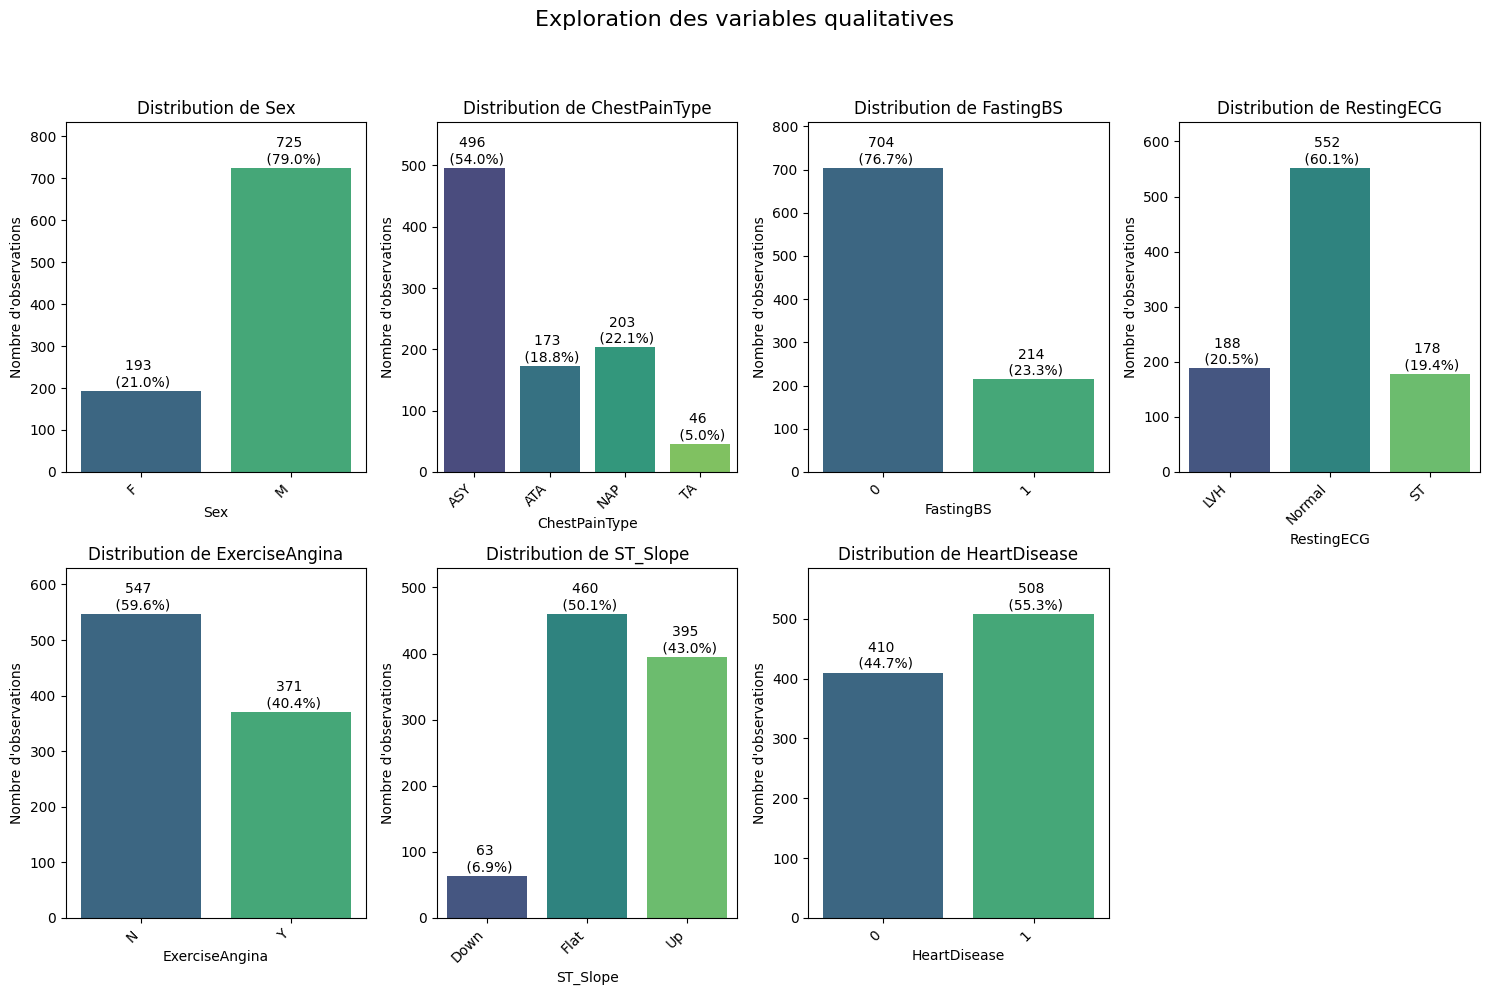

In [ ]:
plot_var_qualitatives(df, 'Exploration des variables qualitatives', 4)

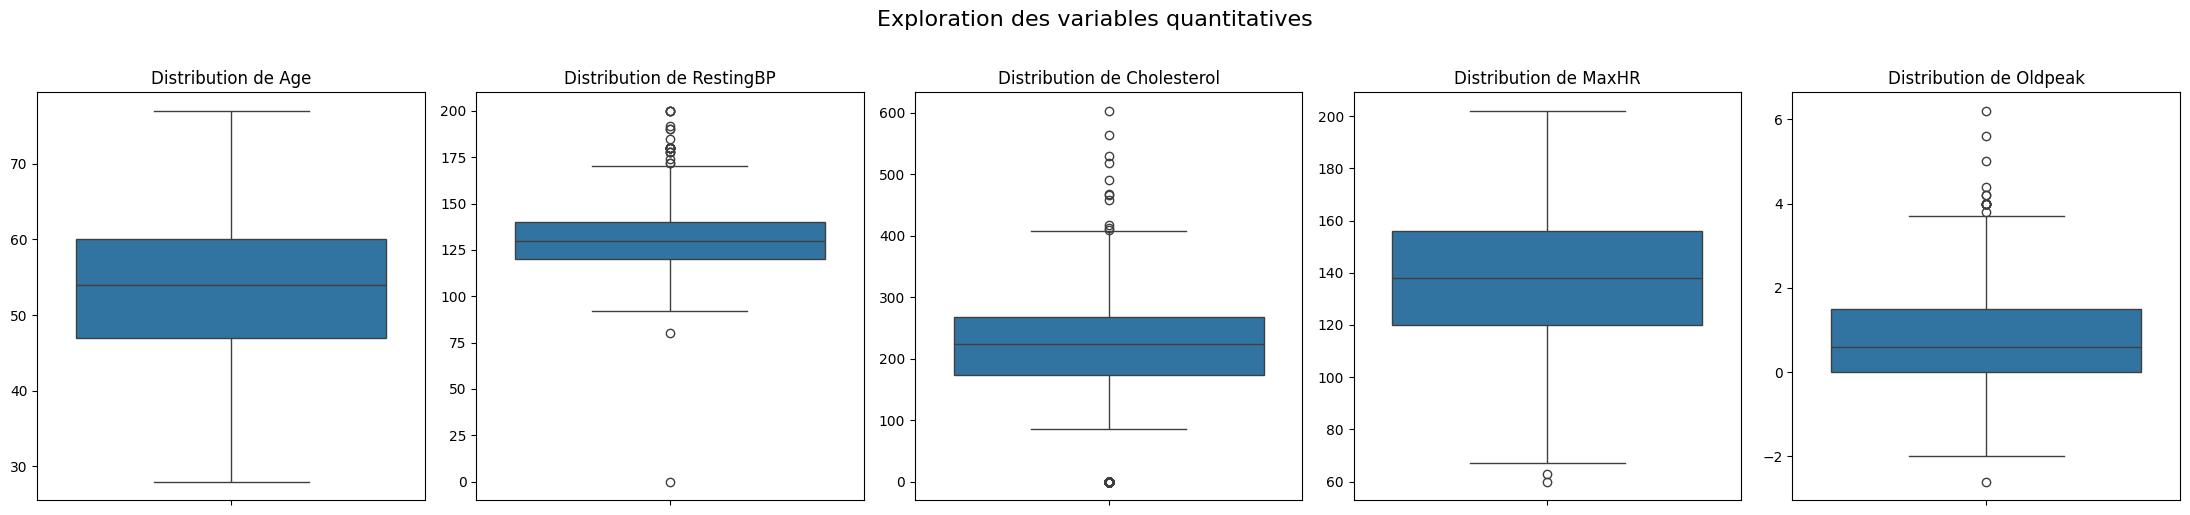

In [ ]:
plot_var_quantitatives(df, 'Exploration des variables quantitatives', 5)

In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


**Analyse :**
- Les variables qualitatives
  - `sex` une sur-représentation masculine (79%)
  - `FastingBS` une prédominance d'absence (76%)
- Les variables quantitatives
  - `Cholesterol` à 0 mg/dl : aberration physiologique évidente, probablement liée à un biais de recueil de données ou à une imputation par défaut lors de la fusion des cohortes.
  - `RestingBP` à 0 mm Hg : donnée physiologiquement impossible, indiquant une erreur de saisie.

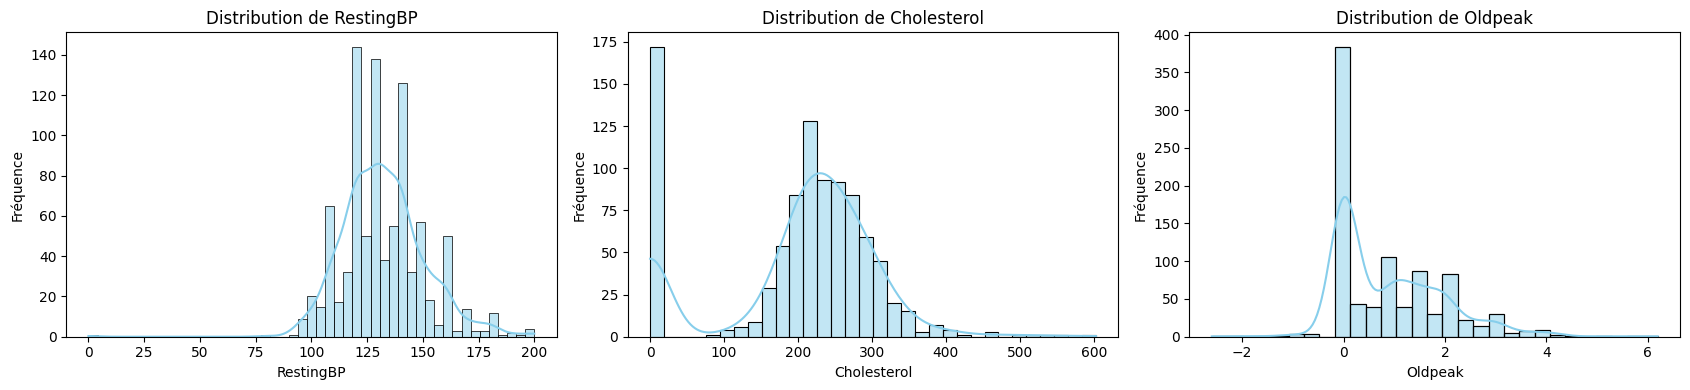

In [ ]:
plt.figure(figsize=(17, 4))
vars_to_plot = ['RestingBP', 'Cholesterol', 'Oldpeak'] # Liste des variables à afficher
for i, col in enumerate(vars_to_plot):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

In [ ]:
vars_to_plot = ['RestingBP', 'Cholesterol']
zero_counts = {}
for col in vars_to_plot:
    zero_counts[col] = (df[col] == 0).sum()

zero_count_df = pd.DataFrame(zero_counts.items(), columns=['Variable', 'Nombre de 0'])

total_rows = len(df)
zero_count_df['Proportion (%)'] = (zero_count_df['Nombre de 0'] / total_rows * 100).round(2)

print("\nNombre de lignes avec la valeur 0 pour chaque variable:")
display(zero_count_df)


Nombre de lignes avec la valeur 0 pour chaque variable:


,Variable,Nombre de 0,Proportion (%)
0,RestingBP,1,0.11
1,Cholesterol,172,18.74


- RestingBP
  - On supprime la ligne concernée
- Cholesterol
  - Ces valeurs nulles représentant près de 19 % de la cohorte, la suppression de ces observations entraînerait une perte d'information excessive. Nous faisons le choix de les recoder en valeurs manquantes (NaN), qui feront l'objet d'une stratégie d'imputation statistique lors de la phase de modélisation.

In [ ]:
# Création d'un df dédiée à la manipulation des données via Machine Learning
df_ml = df.copy()

df_ml = df_ml[df_ml['RestingBP'] != 0]
print(f"Nombre de lignes après suppression des RestingBP à 0 : {len(df_ml)}")

df_ml['Cholesterol'] = df_ml['Cholesterol'].replace(0, np.nan)

Nombre de lignes après suppression des RestingBP à 0 : 917


In [ ]:
df_ml.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,917.000000,917.000000,746.000000,917.000000,917.000000
mean,53.509269,132.540894,244.635389,136.789531,0.886696
std,9.437636,17.999749,59.153524,25.467129,1.066960
min,28.000000,80.000000,85.000000,60.000000,-2.600000
25%,47.000000,120.000000,207.250000,120.000000,0.000000
50%,54.000000,130.000000,237.000000,138.000000,0.600000
75%,60.000000,140.000000,275.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


**Analyse Bivariée** (Facteurs de risque) :
- Avant de croiser les variables dans des modèles complexes, nous confrontons cliniquement chaque variable isolée `X` à l'issue de santé `y`.
- Le but est de dégager visuellement les signaux forts (les déterminants de santé) qui prédisposent à la maladie cardiaque.

<br>

Analyse des variables qualitatives et quantitatives par rapport à `HeartDisease`

In [ ]:
# @title Code => analyse_x_quali()
def analyse_x_quali(dfinput, target_param, titre, n):
    target_name = target_param
    target_series = dfinput[target_param]
    # On définit df_plot sans concaténation si la cible est déjà dans le df
    df_plot = dfinput

    # Identification des variables qualitatives dans les features (en excluant la cible)
    cols_to_plot = [c for c in dfinput.select_dtypes(include=['category']).columns if c != target_name]

    num_plots = len(cols_to_plot)
    num_cols = n
    num_rows = (num_plots + num_cols - 1) // num_cols

    plt.figure(figsize=(15, 5 * num_rows))
    plt.suptitle(titre, y=1.05, fontsize=16)

    for i, col in enumerate(cols_to_plot):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        sns.countplot(data=df_plot, x=col, hue=target_name, palette='viridis', ax=ax, legend=False)
        plt.title(f'{target_name} par {col}')
        plt.xlabel(col)
        plt.ylabel('Nombre d\'observations')
        plt.xticks(rotation=45, ha='right')

        max_height = 0
        for container in ax.containers:
            for patch in container.patches:
                height = patch.get_height()
                max_height = max(max_height, height)
                if height > 0:
                    center_x = patch.get_x() + patch.get_width() / 2
                    category_index = int(round(center_x))

                    if category_index < len(ax.get_xticklabels()):
                        category_label = ax.get_xticklabels()[category_index].get_text()
                    else:
                        continue

                    try:
                        if dfinput[col].dtype.categories.dtype.kind in 'biuf':
                             category_label_converted = float(category_label) if '.' in category_label else int(category_label)
                        else:
                             category_label_converted = category_label
                    except:
                        category_label_converted = category_label

                    total_for_category = dfinput[col].value_counts().get(category_label_converted, 0)

                    if total_for_category > 0:
                        percentage = 100 * height / total_for_category
                        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                                    (center_x, height),
                                    ha='center', va='bottom', fontsize=8,
                                    xytext=(0, 2),
                                    textcoords='offset points')

        if max_height > 0:
            ax.set_ylim(top=max_height * 1.2)

    import matplotlib.patches as mpatches
    palette = sns.color_palette('viridis', 2)
    legend_handles = [mpatches.Patch(color=palette[0], label='Normal'),
                      mpatches.Patch(color=palette[1], label='Maladie cardiaque')]

    plt.figlegend(handles=legend_handles, loc='upper center', ncol=2,
                  bbox_to_anchor=(0.5, 0.98), title=f'Statut: {target_name}')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
# @title Code => analyse_x_quanti()
def analyse_x_quanti(dfinput, target_name, titre, n):
    # Identification des variables quantitatives (excluant la cible si elle est numérique)
    cols_to_plot = [c for c in dfinput.select_dtypes(include=['int64', 'float64']).columns if c != target_name]

    num_plots = len(cols_to_plot)
    num_cols = n
    num_rows = (num_plots + num_cols - 1) // num_cols

    plt.figure(figsize=(22, 6 * num_rows))
    # Augmentation de y pour le titre principal
    plt.suptitle(titre, y=1.08, fontsize=27)

    for i, col in enumerate(cols_to_plot):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        sns.boxplot(data=dfinput, x=target_name, y=col, hue=target_name, palette='viridis', legend=False)
        plt.title(f'Distribution de {col}', fontsize=18, pad=20)
        plt.xlabel(target_name, fontsize=15)
        plt.ylabel(col, fontsize=15)
        plt.xticks(ticks=[0, 1], labels=['Normal', 'Maladie'], fontsize=15)
        plt.yticks(fontsize=15)

    # Ajout d'une légende unique
    palette = sns.color_palette('viridis', 2)
    legend_handles = [mpatches.Patch(color=palette[0], label='Normal (0)'),
                      mpatches.Patch(color=palette[1], label='Maladie cardiaque (1)')]

    # Ajustement du bbox_to_anchor pour remonter la légende
    plt.figlegend(handles=legend_handles, loc='upper center', ncol=2,
                  bbox_to_anchor=(0.5, 1), title=f'Légende {target_name}',
                  fontsize=15, title_fontsize=18)

    # Ajustement du rect pour laisser de la place en haut aux titres/légendes
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

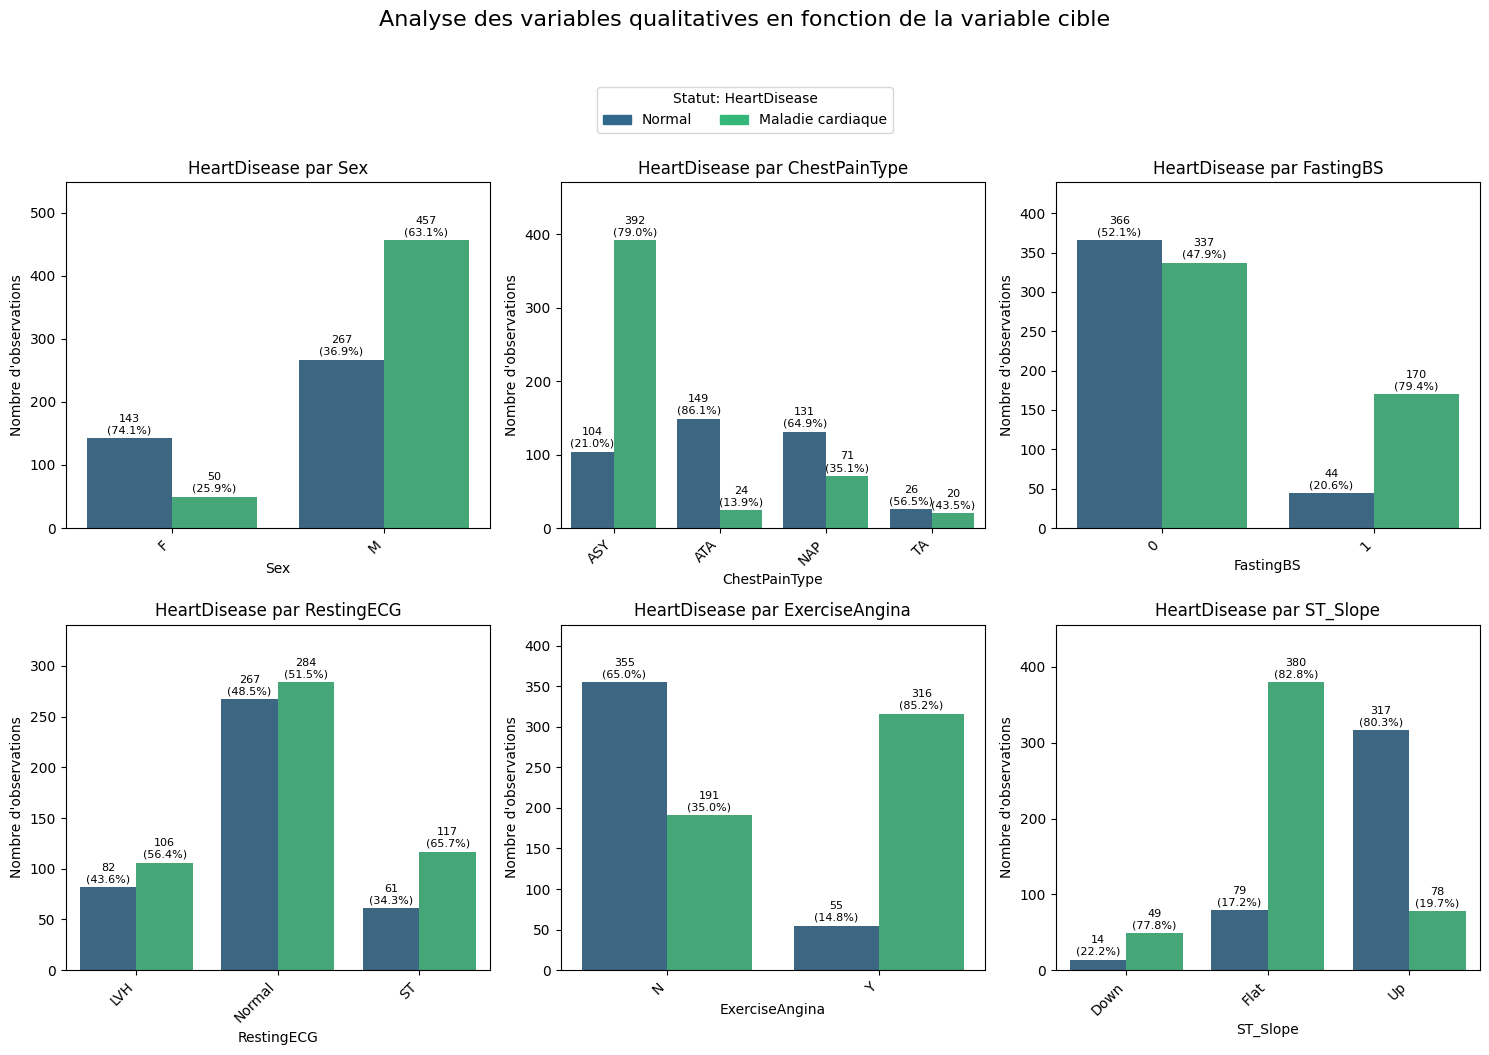

In [ ]:
analyse_x_quali(df_ml, 'HeartDisease', 'Analyse des variables qualitatives en fonction de la variable cible', 3)

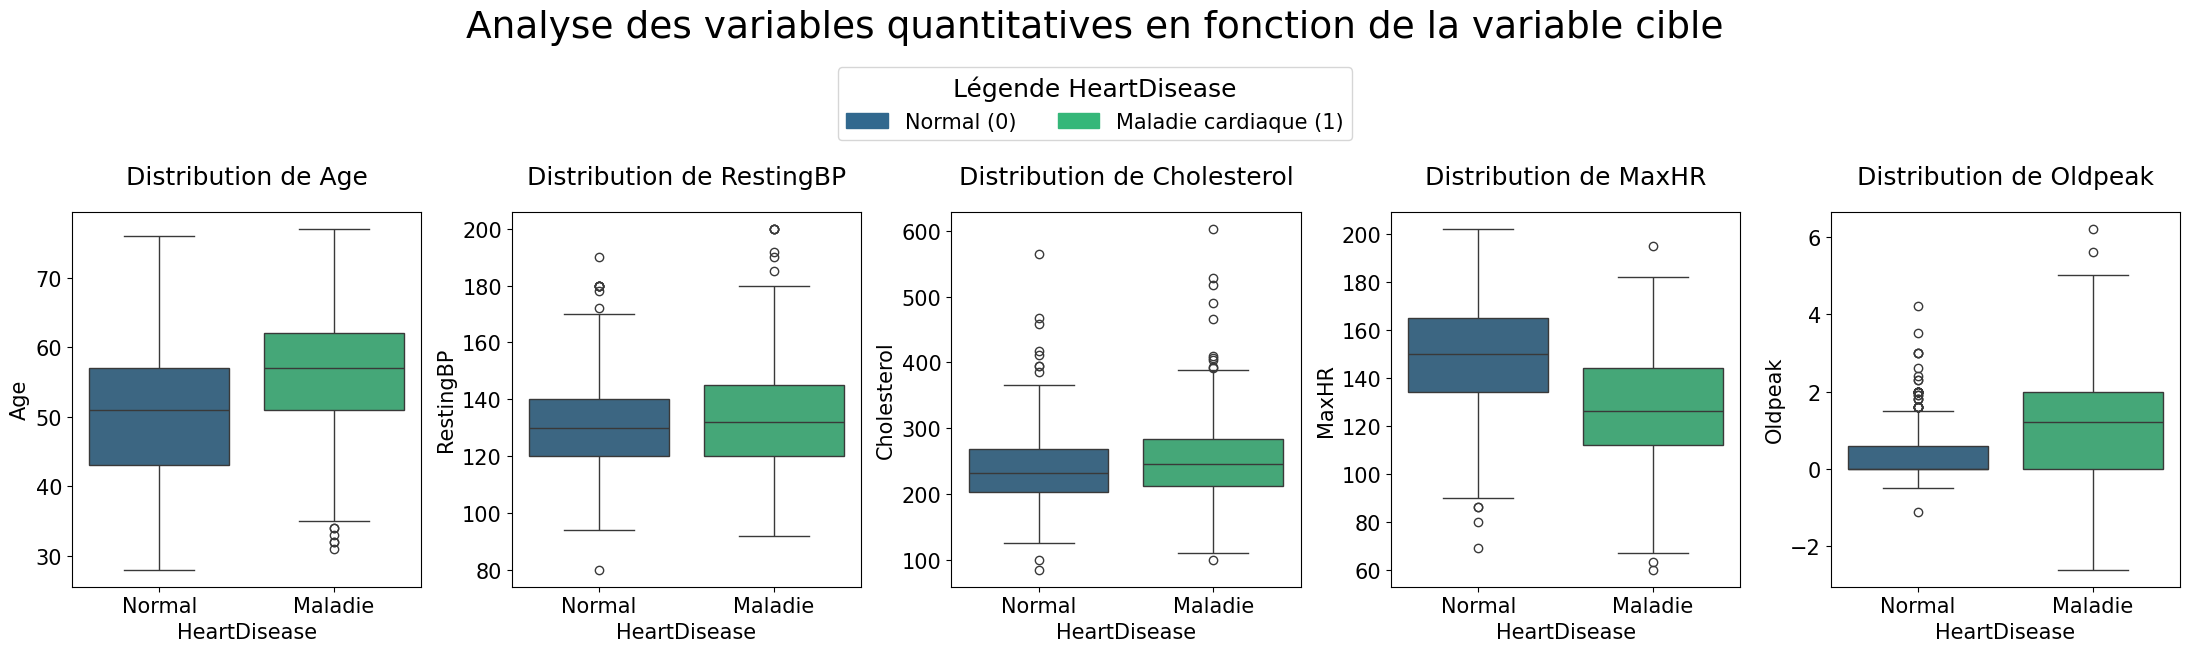

In [ ]:
analyse_x_quanti(df_ml, 'HeartDisease', 'Analyse des variables quantitatives en fonction de la variable cible', 5)

## Selection des variables explicatives

In [ ]:
# Affectation des variables
X = df_ml.drop(columns=['HeartDisease'])
y = df_ml['HeartDisease']

# Création des listes de variables
variables_quali = X.select_dtypes(include=['category']).columns.tolist()
variables_quanti = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

## Choix méthodologiques

- Hold-out
  - Train 80%
  - Test 20%
- Cross-validation
  - StratifiedKFold
  - Shuffled
  - 5
  - 42
- Random Seed
  - 42

**HOLD-OUT (split des données train vs test)**

In [ ]:
# Definition de la répartition entre les jeux de données entrainement et test
X_train, X_hold, y_train, y_hold = train_test_split(
  X, y,
  test_size=0.20,     # établie par la méthodologie
  random_state=42,    # établi par la méthodologie
  stratify=y          # Variable Cible dont on vaut garantir la stratification
)

**CROSS-VALIDATION**

In [ ]:
# Configuration de la cross-validation identique pour tous
choix_cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Analyse de colinéarité

In [ ]:
# @title Code => plot_check_colinear()
def plot_check_colinear(df_input, threshold=0.8):
    df_encoded = df_input.copy()

    # Encodage one-hot pour les variables catégorielles
    categorical_cols = df_encoded.select_dtypes(include='category').columns
    df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

    # Calcul de la matrice de corrélation
    corr_matrix = df_encoded.corr().abs()

    # Configuration de la figure pour la heatmap
    plt.figure(figsize=(10, 8)) # Réduction de la taille de la figure

    # Création d'un masque pour afficher uniquement le triangle supérieur
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, mask=mask)
    plt.title('Matrice de Corrélation (Valeur Absolue) des Variables')
    plt.show()

    # Identification des paires fortement colinéaires
    highly_correlated_pairs = []
    # Itérer sur la partie triangulaire supérieure de la matrice pour éviter les doublons et les corrélations avec soi-même
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                highly_correlated_pairs.append((col1, col2, corr_matrix.iloc[i, j]))

    if highly_correlated_pairs:
        print(f"\nPaires de variables fortement colinéaires (corrélation absolue > {threshold}):")
        for col1, col2, corr_value in highly_correlated_pairs:
            print(f"  - {col1} et {col2}: {corr_value:.2f}")
    else:
        print(f"\nAucune paire de variables n'a été trouvée avec une corrélation absolue supérieure à {threshold}.")

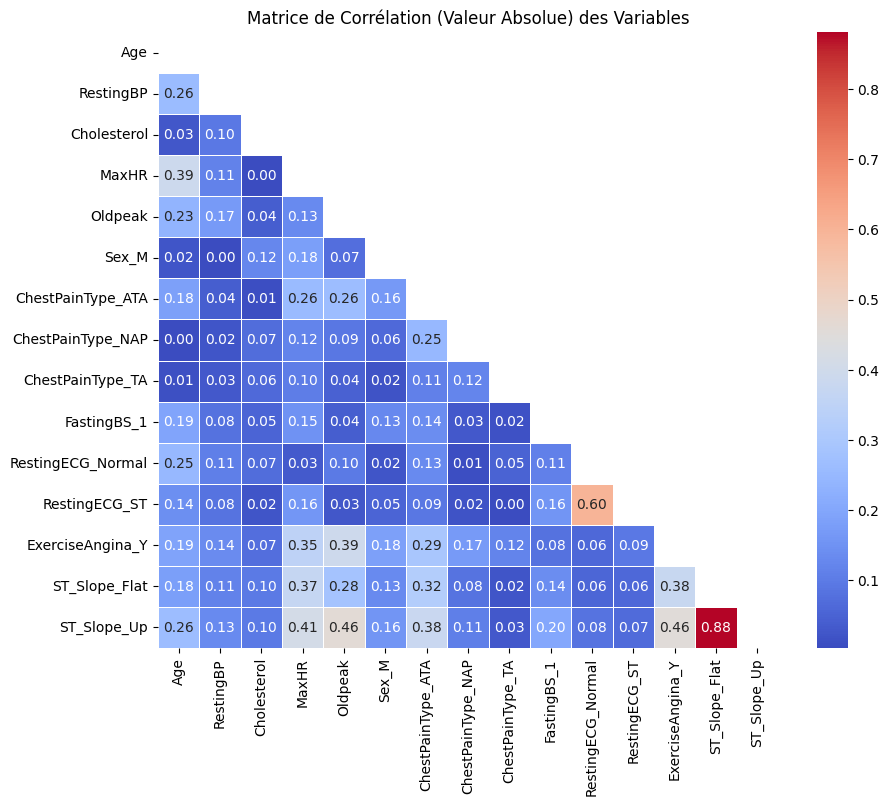


Paires de variables fortement colinéaires (corrélation absolue > 0.8):
  - ST_Slope_Flat et ST_Slope_Up: 0.88


In [ ]:
# On cherche les variables ayant une forte colinéarité (encodage one-hot temporaire pour identifier)
plot_check_colinear(X_train, 0.8)

## Pipeline de pre-traitement

Nous allons décrire une `pipeline`avec `sklearn` afin de traiter les différentes variables selon leurs natures à l'occasion des différents apprentissages, tout en évitant les problématiques de data-leakage.

Deux grandes familles de variables sont présentes dans le dataset ainsi nous allons les traiter différement :
- **Variables Qualitatives** :
  - Imputation : `SimpleImputer` basé sur la fréquence
  - Encodage : `One-hot` car mieux supporté que le `label encoding` et adapté pour l'ensemble des modèles choisi.

- **Variables Quantitatives** :
  - Imputation : `SimpleImputer` basé sur la médiane, afin de conserver les observations (le jeu de donnée étant assez modeste)
    - Echelle : `RobustScaler` qui supporte mieux des outliers de notre jeu de donnée.


In [ ]:
# Configuration de la pipeline de pré-process identique pour tous
# Pipeline pour les variables Qualitatives (Séquentiel)
pipe_quali = Pipeline(steps=[
    ('quali_imputer', SimpleImputer(strategy='most_frequent')),
    ('quali_encoder', OneHotEncoder(handle_unknown='ignore')) # pas besoin de scaler car entre 0 et 1
])

# Pipeline pour les variables Quantitatives (Séquentiel)
pipe_quanti = Pipeline(steps=[
    ('quanti_imputer', SimpleImputer(strategy='median')),
    ('quanti_scaler', RobustScaler())
])

## Choix des critères d'évaluation

Nous privilégions le recall (sensibilité) car manquer un patient malade est plus grave qu'un faux positif.

- Collecte des métriques :
  - Matrice de confusion pour diagnostiquer la prédiction
  - precision pour mesurer la fiabilité
  - recall pour mesurer la sensibilité
  - f1-score pour avoir un indicateur rassemblant fiabilité et sensibilité
  - accuracy pour mesurer le taux de succès
  - roc_auc pour mesurer la discrimination du classifieur
  - brier pour mesurer la calibration du classifieur
  - neg_log_loss pour mesurer la confiance

- Choix du critère pivot pour selection du refit
  - Dans notre cas de comparaison de modèles, nous utiliserons le `roc_auc`.
  - Si nous avions à faire des prédictions médicales, nous aurions plutôt choisi un refit sur la minimisation du `recall`
    - Le fait prédire un patient sain alors qu'il est malade est un problème important qui doit être minimisé.

In [ ]:
choix_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss', 'neg_brier_score']
choix_refit = 'roc_auc'

## Choix des méthodes d'interprétabilité

Nous analyserons la contribution des variables à travers trois niveaux d'interprétabilité :

- Pour la Régression Logistique (Interprétabilité intrinsèque) :
  - Calcul des Odds Ratios (Rapports des côtes) pour quantifier l'impact de chaque facteur sur le risque.

- Pour les modèles basés sur les arbres (Random Forest & XGBoost) :
  - MDI (Mean Decrease Impurity) : Importance basée sur le gain de pureté dans l'arbre.
  - MDA (Mean Decrease Accuracy) : Importance par permutation, mesurant la perte de performance du modèle.
  - Visualisation structurelle : Analyse d'un arbre de décision individuel pour comprendre les règles de décision.

- Méthodes Agnostiques (Indépendantes du modèle) :
  - SHAP (SHapley Additive exPlanations) : Pour l'attribution de la contribution de chaque variable à la prédiction individuelle.
  - PDP (Partial Dependence Plots) : Pour visualiser la relation (linéaire ou non) entre une variable et la probabilité prédite.

# 3-Apprentissages

## Choix des modèles

Objectifs de l'étape : Performance, augmentation de l'intéprétabilité, supprimer les colinéarités, réduire le bruit

- Régression Logistique
- KNN
- Random Forest
- XGBoost

In [ ]:
# On attribue des couleurs par modèle pour l'ensemble des plots
color_map = {
  'LR': '#1f77b4',  # Bleu
  'RF': '#ff7f0e',  # Orange
  'KNN': '#2ca02c', # Vert
  'XGB': '#d62728'  # Rouge
}

In [ ]:
lst_Estimateurs = []
choix_verbose = 1 # permet d'afficher le nombre de fit

### **Régression Logistique (LR)**

Modèle linéaire de référence, directement interprétable via les Odds Ratios.

Pour une `LogisticRegression ` nous avons plusieurs valeurs disponibles :
- `C` qui permet d'influencer le compris biais-variance
  - Valeur faible, tendance à l'underfitting
  - Valeur forte, tendance à l'overfitting
- `max_iter` qui permet de limiter le nombre d'itération si il ne converge pas
- `solver` qui permet de choisir les modèles de régression logistique
  - `lbfgs` => Données de taille moyenne.
  - `liblinear` => Petits jeux de données. Méthode de descente de coordonnées.
  - `newton-cg` => Données multidimensionnelles, précision élevée (second ordre).
  - `sag` => Très grands jeux de données
  - `saga` => Très grands jeux de données
  - `newton-cholesky` => Très efficace si  n >>  p.
- `penalty` qui permet de chosir la méthode de régularisation ou pénalité
    - `L1` => LASSO
      - Solvers compatibles : `liblinear` `saga`
    - `L2` => Ridge
      - Solvers compatibles : `lbfgs` `liblinear` `sag` `saga` `newton-cg` `newton-cholesky`
    - `ElasticNet` => Mix L1 & L2
      - Solvers compatibles : `saga`
    - `None`
      - Solvers compatibles : `lbfgs` `sag` `saga` `newton-cg` `newton-cholesky`

<br>

Notre dataset et le nombre de variable étant modeste nous allons utiliser :
- Le solveur `liblinear`
- Les pénalités `l1` et `l2`
- Une limite d'itération à `2000`

In [ ]:
# Défintion de la pipeline pour la Regression Logistique
# Regroupement par type de colonnes (Parallèle)
preprocessor_LR = ColumnTransformer(transformers=[
    ('pipe_quali', pipe_quali, variables_quali),
    ('pipe_quanti', pipe_quanti, variables_quanti)
])

# Définition de la pipeline finale (Préprocess + Modèle)
pipeline_LR = Pipeline(steps=[
    ('prep_LR', preprocessor_LR),
    ('LR', LogisticRegression(random_state=42))
])

In [ ]:
# Défintion du Grid Search
param_grid_LR = {
    'LR__solver': ['liblinear'],
    'LR__penalty': ['l1', 'l2'],
    'LR__C': [0.5, 0.8, 1.0, 1.2, 1.5],
    'LR__max_iter': [2000]
}

In [ ]:
# Défintion de l'estimateur
estimateur_LR = GridSearchCV(
  estimator=pipeline_LR,      # propre à chaque modèle
  param_grid=param_grid_LR,   # propre à chaque modèle
  cv=choix_cv,                # défini par la méthodo
  refit=choix_refit,          # défini par la méthodo
  scoring=choix_scoring,      # défini par la méthodo (et faire la dataviz)
  return_train_score=True,    # Pour faire de la dataviz
  n_jobs=-1
)

# On l'ajoute à la boucle de traitement
lst_Estimateurs.append(('LR', estimateur_LR))

### **K-Nearest Neighbors (KNN)**

Méthode non paramétrique, adaptée aux structures locales du dataset.

In [ ]:
# Défintion de la pipeline pour le KNN
# Regroupement par type de colonnes (Parallèle)
preprocessor_KNN = ColumnTransformer(transformers=[
    ('pipe_quali', pipe_quali, variables_quali),
    ('pipe_quanti', pipe_quanti, variables_quanti)
])

# Définition de la pipeline finale (Préprocess + Modèle)
pipeline_KNN = Pipeline(steps=[
    ('prep_KNN', preprocessor_KNN),
    ('KNN', KNeighborsClassifier())
])

In [ ]:
# Défintion du Grid Search
param_grid_KNN = {
    'KNN__n_neighbors': [43,45,47],
    'KNN__weights': ['uniform'],
    'KNN__metric': ['manhattan', 'minkowski'],
    'KNN__p': [1]
}

In [ ]:
# Défintion de l'estimateur
estimateur_KNN = GridSearchCV(
  estimator=pipeline_KNN,     # propre à chaque modèle
  param_grid=param_grid_KNN,  # propre à chaque modèle
  cv=choix_cv,                # défini par la méthodo
  refit=choix_refit,          # défini par la méthodo
  scoring=choix_scoring,      # défini par la méthodo (et faire la dataviz)
  return_train_score=True,    # Pour faire de la dataviz
  n_jobs=-1
)

# On l'ajoute à la boucle de traitement
lst_Estimateurs.append(('KNN', estimateur_KNN))

### **Random Forest (RF)**

Ensemble par bagging, capture les non-linéarités et réduit la variance.


In [ ]:
# Défintion de la pipeline pour la Random Forest
# Regroupement par type de colonnes (Parallèle)
preprocessor_RF = ColumnTransformer(transformers=[
    ('pipe_quali', pipe_quali, variables_quali),
    ('pipe_quanti', pipe_quanti, variables_quanti)
])

# Définition de la pipeline finale (Préprocess + Modèle)
pipeline_RF = Pipeline(steps=[
    ('prep_RF', preprocessor_RF),
    ('RF', RandomForestClassifier(random_state=42, oob_score=True))
])

In [ ]:
# Défintion du Grid Search
param_grid_RF = {
    'RF__max_depth': [8],
    'RF__min_samples_split': [5],
    'RF__min_samples_leaf': [2, 3, 4],
    'RF__max_features': ['sqrt'],
    'RF__n_estimators': [400],
    'RF__class_weight': [None]
}

In [ ]:
# Défintion de l'estimateur
estimateur_RF = GridSearchCV(
  estimator=pipeline_RF,      # propre à chaque modèle
  param_grid=param_grid_RF,   # propre à chaque modèle
  cv=choix_cv,                # défini par la méthodo
  refit=choix_refit,          # défini par la méthodo
  scoring=choix_scoring,      # défini par la méthodo (et faire la dataviz)
  return_train_score=True,    # Pour faire de la dataviz
  n_jobs=-1
)

# On l'ajoute à la boucle de traitement
lst_Estimateurs.append(('RF', estimateur_RF))

### **eXtreme Gradient Boosting (XGB)**

Gradient boosting régularisé, état de l'art sur données tabulaires.

In [ ]:
# Défintion de la pipeline pour le XGB
preprocessor_XGB = ColumnTransformer(transformers=[
    ('quali', pipe_quali, variables_quali),
    ('quanti', pipe_quanti, variables_quanti)
])

# 2. Pipeline Finale (Pré-traitement + Modèle XGBoost)
# On retire 'use_label_encoder=False' car il est obsolète
pipeline_XGB = Pipeline(steps=[
    ('prep_XGB', preprocessor_XGB),
    ('XGB', XGBClassifier(random_state=42, eval_metric='auc'))
])

In [ ]:
# Définition de la grille de recherche (Hyperparamètres XGBoost)
param_grid_XGB = {
    'XGB__max_depth': [5, 6],
    'XGB__learning_rate': [0.05, 0.1],
    'XGB__n_estimators': [100, 150],
    'XGB__gamma': [1],
    'XGB__reg_lambda': [1],
    'XGB__subsample': [0.8],
    'XGB__colsample_bytree': [0.8],
    'XGB__scale_pos_weight': [3]
}

In [ ]:
# Défintion de l'estimateur
estimateur_XGB = GridSearchCV(
  estimator=pipeline_XGB,     # propre à chaque modèle
  param_grid=param_grid_XGB,  # propre à chaque modèle
  cv=choix_cv,                # défini par la méthodo
  refit=choix_refit,          # défini par la méthodo
  scoring=choix_scoring,      # défini par la méthodo (et pour faire la dataviz)
  return_train_score=True,    # Pour faire de la dataviz
  n_jobs=-1
)

# On l'ajoute à la boucle de traitement
lst_Estimateurs.append(('XGB', estimateur_XGB))

In [ ]:
# @title Code => Entrainement des modèles (fit)
# Création d'un DF vierge pour stocker les métriques de l'ensemble des modèles
rslt_estimateurs = {}

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

for code, estimateur in lst_Estimateurs:
  print(" ")
  print("Training => "+code)
  display(estimateur.fit(X_train, y_train))

  print(f" - Meilleure configuration : {estimateur.best_params_}")
  print(f" - Meilleur score de validation croisée : {estimateur.best_score_:.4f}")
  print(" ")
  print(f" =======================================================================")

  # exporte les résultats pour la Dataviz
  rslt_estimateurs[code] = estimateur



 
Training => LR


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep_LR',
                                        ColumnTransformer(transformers=[('pipe_quali',
                                                                         Pipeline(steps=[('quali_imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('quali_encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'ChestPainType',
                                                                          'FastingBS',
                                                                          'RestingECG',
                                                                          'ExerciseAngi...
                                                                          'RestingBP',
                                                                          'Cholesterol',
                                                                          'MaxHR',
                                                                          'Oldpeak'])])),
                                       ('LR',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'LR__C': [0.5, 0.8, 1.0, 1.2, 1.5],
                         'LR__max_iter': [2000], 'LR__penalty': ['l1', 'l2'],
                         'LR__solver': ['liblinear']},
             refit='roc_auc', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc',
                      'neg_log_loss', 'neg_brier_score'])

 - Meilleure configuration : {'LR__C': 0.8, 'LR__max_iter': 2000, 'LR__penalty': 'l1', 'LR__solver': 'liblinear'}
 - Meilleur score de validation croisée : 0.9179
 
 
Training => KNN


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep_KNN',
                                        ColumnTransformer(transformers=[('pipe_quali',
                                                                         Pipeline(steps=[('quali_imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('quali_encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'ChestPainType',
                                                                          'FastingBS',
                                                                          'RestingECG',
                                                                          'ExerciseAng...
                                                                         ['Age',
                                                                          'RestingBP',
                                                                          'Cholesterol',
                                                                          'MaxHR',
                                                                          'Oldpeak'])])),
                                       ('KNN', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'KNN__metric': ['manhattan', 'minkowski'],
                         'KNN__n_neighbors': [43, 45, 47], 'KNN__p': [1],
                         'KNN__weights': ['uniform']},
             refit='roc_auc', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc',
                      'neg_log_loss', 'neg_brier_score'])

 - Meilleure configuration : {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 47, 'KNN__p': 1, 'KNN__weights': 'uniform'}
 - Meilleur score de validation croisée : 0.9258
 
 
Training => RF


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep_RF',
                                        ColumnTransformer(transformers=[('pipe_quali',
                                                                         Pipeline(steps=[('quali_imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('quali_encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'ChestPainType',
                                                                          'FastingBS',
                                                                          'RestingECG',
                                                                          'ExerciseAngi...
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'RF__class_weight': [None], 'RF__max_depth': [8],
                         'RF__max_features': ['sqrt'],
                         'RF__min_samples_leaf': [2, 3, 4],
                         'RF__min_samples_split': [5],
                         'RF__n_estimators': [400]},
             refit='roc_auc', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc',
                      'neg_log_loss', 'neg_brier_score'])

 - Meilleure configuration : {'RF__class_weight': None, 'RF__max_depth': 8, 'RF__max_features': 'sqrt', 'RF__min_samples_leaf': 2, 'RF__min_samples_split': 5, 'RF__n_estimators': 400}
 - Meilleur score de validation croisée : 0.9322
 
 
Training => XGB


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep_XGB',
                                        ColumnTransformer(transformers=[('quali',
                                                                         Pipeline(steps=[('quali_imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('quali_encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'ChestPainType',
                                                                          'FastingBS',
                                                                          'RestingECG',
                                                                          'ExerciseAngina',...
             n_jobs=-1,
             param_grid={'XGB__colsample_bytree': [0.8], 'XGB__gamma': [1],
                         'XGB__learning_rate': [0.05, 0.1],
                         'XGB__max_depth': [5, 6],
                         'XGB__n_estimators': [100, 150],
                         'XGB__reg_lambda': [1], 'XGB__scale_pos_weight': [3],
                         'XGB__subsample': [0.8]},
             refit='roc_auc', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc',
                      'neg_log_loss', 'neg_brier_score'])

 - Meilleure configuration : {'XGB__colsample_bytree': 0.8, 'XGB__gamma': 1, 'XGB__learning_rate': 0.05, 'XGB__max_depth': 5, 'XGB__n_estimators': 100, 'XGB__reg_lambda': 1, 'XGB__scale_pos_weight': 3, 'XGB__subsample': 0.8}
 - Meilleur score de validation croisée : 0.9344
 


In [ ]:
# @title Code => plot_metrics_best_estimateurs()
def plot_metrics_best_estimateurs(rslt_estimateurs, lst_estimateur_names, choix_scoring, color_map=color_map):
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    fig.suptitle('Performance des Meilleurs Estimateurs (Validation Croisée)', fontsize=18, y=0.98)

    # --- Subplot 1: ROC Curves (CV) ---
    ax_roc = axes[0]
    for name in lst_estimateur_names:
        if name in rslt_estimateurs:
            # On récupère les données de la meilleure config
            df_results = pd.DataFrame(rslt_estimateurs[name].cv_results_)
            best_idx = df_results['rank_test_roc_auc'].idxmin()

            # Note: GridSearchCV ne stocke pas directement les courbes ROC par fold dans cv_results_,
            # on utilise donc le best_estimator_ sur le train pour une estimation visuelle cohérente
            best_est = rslt_estimateurs[name].best_estimator_
            y_proba_train = best_est.predict_proba(X_train)[:, 1]
            fpr, tpr, _ = roc_curve(y_train, y_proba_train)
            auc_score = roc_auc_score(y_train, y_proba_train)

            ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})', color=color_map.get(name, 'gray'))

    ax_roc.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
    ax_roc.set_xlabel('Taux de faux positifs (FPR)')
    ax_roc.set_ylabel('Taux de vrais positifs (TPR)')
    ax_roc.set_title('Courbes ROC (Train/Val)')
    ax_roc.grid(True)

    # --- Subplot 2: Barplot des Métriques ---
    ax_metrics = axes[1]
    data_for_plot = []

    for estimator_name in lst_estimateur_names:
        df_results = pd.DataFrame(rslt_estimateurs[estimator_name].cv_results_)
        best_config_row = df_results[df_results['rank_test_roc_auc'] == 1].iloc[0]

        for metric in choix_scoring:
            mean_score_col = f'mean_test_{metric}'
            if mean_score_col in best_config_row:
                score = best_config_row[mean_score_col]
                display_name = metric.replace('neg_', '')
                display_score = abs(score) if metric.startswith('neg_') else score
                data_for_plot.append({'Metric': display_name, 'Estimator': estimator_name, 'Score': display_score})

    if data_for_plot:
        df_plot = pd.DataFrame(data_for_plot)
        sns.barplot(data=df_plot, y='Metric', x='Score', hue='Estimator', palette=color_map, ax=ax_metrics, legend=False)
        ax_metrics.set_title('Comparaison des Métriques (CV Scores)')
        ax_metrics.grid(axis='x', linestyle='--', alpha=0.7)

        for container in ax_metrics.containers:
            ax_metrics.bar_label(container, fmt='%.3f', padding=3)

        _, x_max = ax_metrics.get_xlim()
        ax_metrics.set_xlim(0, x_max * 1.15)

    # Légende globale
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=len(lst_estimateur_names) + 1, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.subplots_adjust(top=0.82, wspace=0.15)
    plt.show()

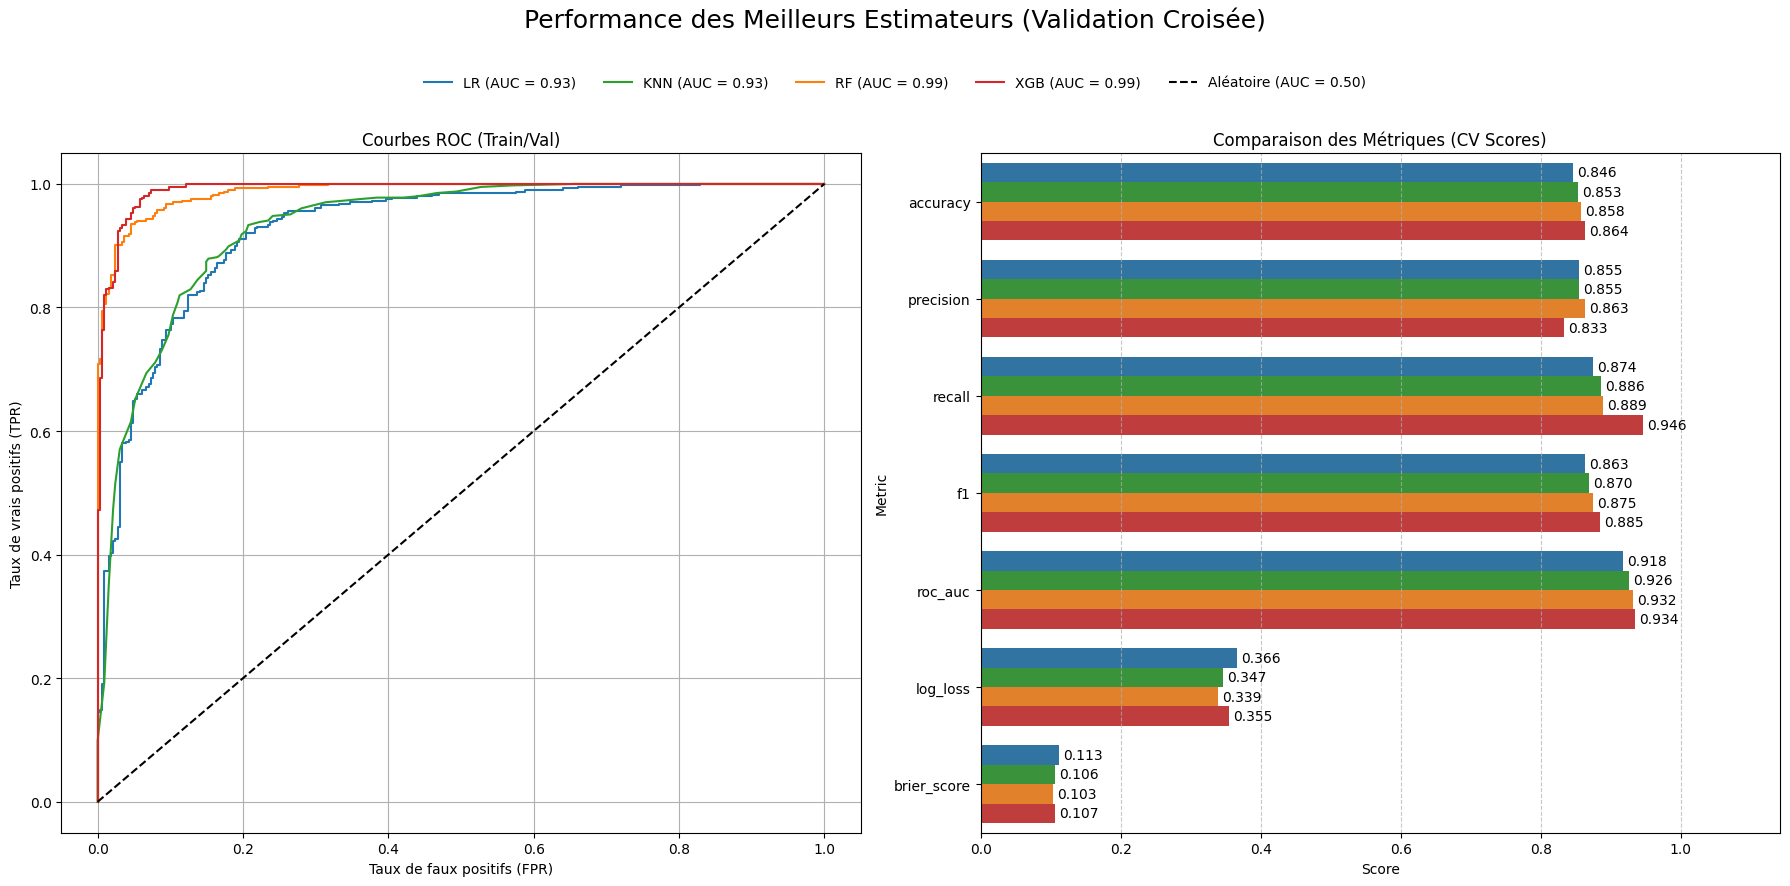

In [ ]:
plot_metrics_best_estimateurs(rslt_estimateurs, ['LR', 'KNN', 'RF', 'XGB'] , choix_scoring)

In [ ]:
# @title Code => plot_learning_curve()
def plot_learning_curve(rslt_estimateurs, estimator_names, X, y, cv=choix_cv, scoring=choix_refit, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10), n_cols=2):
    num_estimators = len(estimator_names)
    n_rows = (num_estimators + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5), squeeze=False)
    axes = axes.flatten() # Aplatir l'array pour itérer facilement

    for i, name in enumerate(estimator_names):
        if name not in rslt_estimateurs:
            print(f"Estimateur '{name}' non trouvé dans les résultats.")
            continue

        # Récupérer le meilleur estimateur de GridSearchCV
        estimator = rslt_estimateurs[name].best_estimator_
        ax = axes[i]

        train_sizes_out, train_scores, test_scores = learning_curve(
            estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring=scoring
        )

        train_scores_mean = np.mean(train_scores, axis=1)
        train_scores_std = np.std(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)
        test_scores_std = np.std(test_scores, axis=1)

        # Tracer la courbe d'apprentissage
        ax.plot(train_sizes_out, train_scores_mean, 'o-', color="r",
                label="Score d'entraînement")
        ax.fill_between(train_sizes_out, train_scores_mean - train_scores_std,
                        train_scores_mean + train_scores_std, alpha=0.1, color="r")
        ax.plot(train_sizes_out, test_scores_mean, 'o-', color="g",
                label="Score de validation croisée")
        ax.fill_between(train_sizes_out, test_scores_mean - test_scores_std,
                        test_scores_mean + test_scores_std, alpha=0.1, color="g")

        ax.set_title(f"Courbe d'apprentissage pour {name}")
        ax.set_xlabel("Taille de l'ensemble d'entraînement")
        ax.set_ylabel("Score")
        ax.grid(True)

    # Masquer les subplots non utilisés s'il y en a
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Création d'une légende unique globale au dessus des subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
               ncol=2, frameon=True, fontsize='large')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

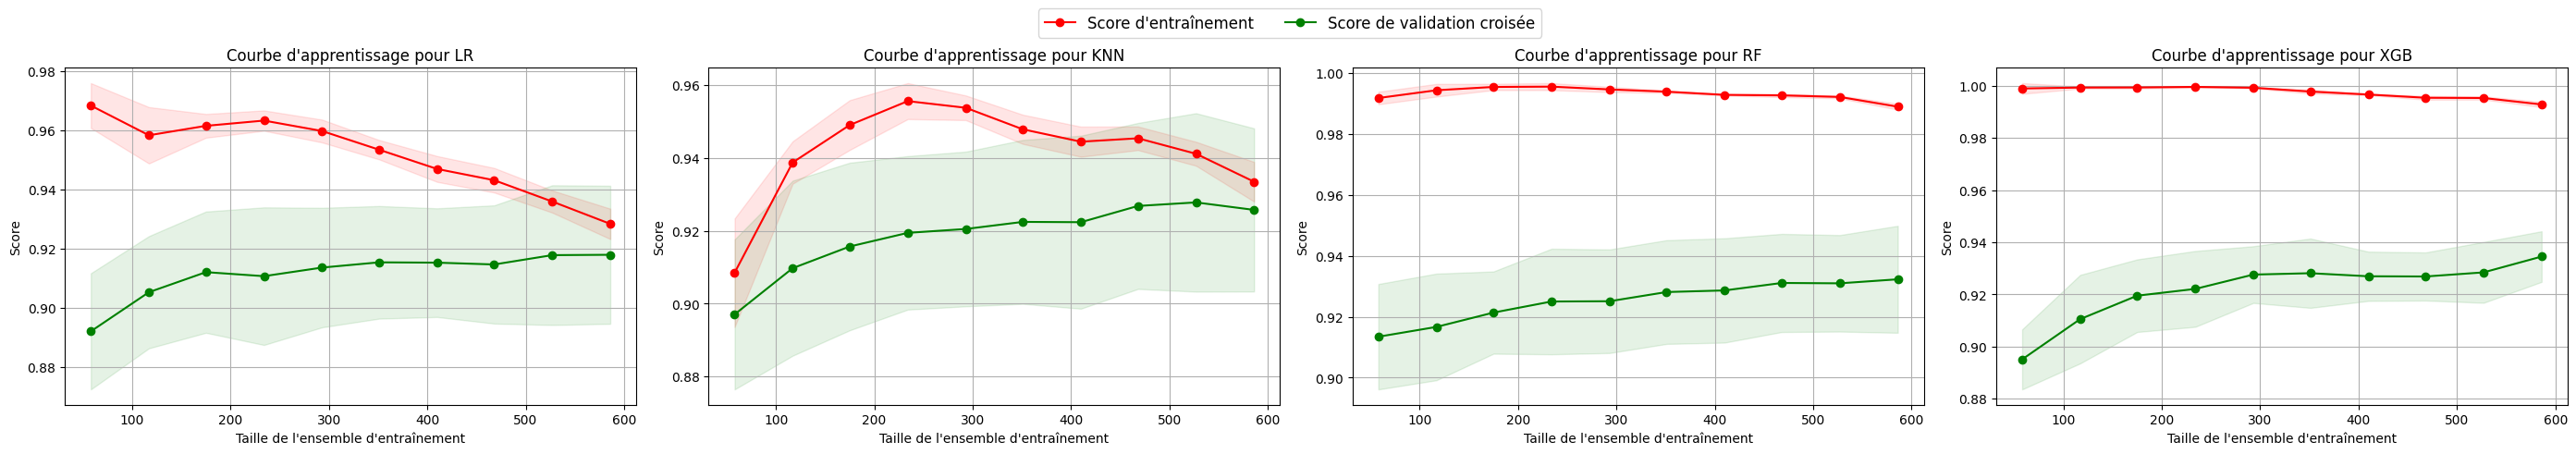

In [ ]:
plot_learning_curve(rslt_estimateurs, ['LR', 'KNN', 'RF', 'XGB'], X_train, y_train, n_cols=4)

In [ ]:
# @title Code => plot_learning_curve2()
def plot_learning_curve2(rslt_estimateurs, estimator_names, X, y, cv=choix_cv, scoring=choix_refit, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10), color_map=color_map):
    plt.figure(figsize=(12, 5))

    for name in estimator_names:
        if name not in rslt_estimateurs: continue

        estimator = rslt_estimateurs[name].best_estimator_

        train_sizes_out, train_scores, test_scores = learning_curve(
            estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring=scoring
        )

        # Calcul des moyennes
        train_scores_mean = np.mean(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)

        current_color = color_map.get(name, 'black')

        # Affichage des courbes : pointillés pour le train, ligne pleine pour la validation
        plt.plot(train_sizes_out, train_scores_mean, '--', color=current_color, alpha=0.3)
        plt.plot(train_sizes_out, test_scores_mean, 'o-', color=current_color, label=f"{name} (Val)")

    plt.title("Comparaison des courbes d'apprentissage (Validation)", fontsize=16)
    plt.xlabel("Taille d'entraînement")
    plt.ylabel(f"Score ({scoring})")
    plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


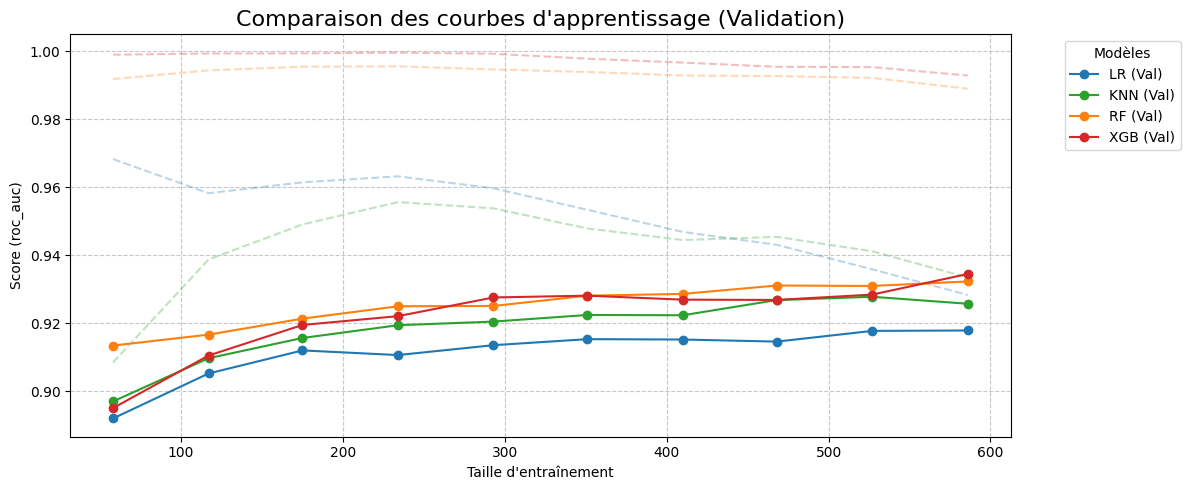

In [ ]:
plot_learning_curve2(rslt_estimateurs, ['LR', 'KNN', 'RF', 'XGB'], X_train, y_train)

# 4-Résultats

Cette section présente les performances comparées des 4 modèles sur l'ensemble de maintien et la validation croisée.

In [ ]:
# @title Code => Calcul des prédictions
# Calcul et stockage des métriques sur l'ensemble de maintien (X_hold, y_hold)

for code, estimateur_grid in lst_Estimateurs:
    print(f"Processing hold-out results for: {code}")
    best_estimator = estimateur_grid.best_estimator_

    # Faire les prédictions sur l'ensemble de maintien
    y_pred_hold = best_estimator.predict(X_hold)
    y_proba_hold = best_estimator.predict_proba(X_hold)[:, 1]

    # Calculer les métriques
    metrics = {
        'accuracy': accuracy_score(y_hold, y_pred_hold),
        'precision': precision_score(y_hold, y_pred_hold, zero_division=0),
        'recall': recall_score(y_hold, y_pred_hold, zero_division=0),
        'f1': f1_score(y_hold, y_pred_hold, zero_division=0),
        'roc_auc': roc_auc_score(y_hold, y_proba_hold),
        'neg_log_loss': -log_loss(y_hold, y_proba_hold) # négatif car choix_scoring utilise neg_log_loss
    }

    # Calculer la courbe ROC
    fpr, tpr, thresholds = roc_curve(y_hold, y_proba_hold)
    roc_curve_data = {'fpr': fpr, 'tpr': tpr, 'roc_auc': metrics['roc_auc']}

    # Stocker les résultats dans rslt_estimateurs en tant qu'attribut de l'objet GridSearchCV
    if not hasattr(rslt_estimateurs[code], 'hold_results'):
        rslt_estimateurs[code].hold_results = {}
    rslt_estimateurs[code].hold_results['metrics'] = metrics
    rslt_estimateurs[code].hold_results['roc_curve'] = roc_curve_data


Processing hold-out results for: LR
Processing hold-out results for: KNN
Processing hold-out results for: RF
Processing hold-out results for: XGB


## Comparaison des modèles
Nous allons comparer la performance des différents modèles retenues sous plusieurs angles :
- Rappel des hyperparamètres retenu
- Matrices de confusion
- Courbes de performance `roc_auc`
- Scores `Precision`, `Recall`, `Accuracy` et `f1`
- Scores de confiance `log_loss` et `brier`
- Courbes de calibration et l'indice `ECE`

In [ ]:
# @title Code => Hyperparamètres
# Extraction et mise en forme esthétique des meilleurs hyperparamètres
best_params_list = []

for code, grid_search in rslt_estimateurs.items():
    # Nettoyage des clés et formatage sans accolades
    clean_params = ", ".join([f"{k.split('__')[-1]}: {v}" for k, v in grid_search.best_params_.items()])
    best_params_list.append({
        'Modèle': code,
        'Paramètres optimaux': clean_params
    })

df_params = pd.DataFrame(best_params_list)

# Style du tableau pour mettre en valeur les paramètres
styled_df = df_params.style.set_properties(**{
    'text-align': 'left',
    'padding': '12px',
    'border-bottom': '1px solid #ddd'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f1f1f1')]}
]).set_properties(subset=['Paramètres optimaux'], **{
    'background-color': '#e8f4fd', # Mise en évidence
    'color': '#1a5276',
    'font-weight': 'bold'
}).hide(axis='index')

display(styled_df)

Modèle,Paramètres optimaux
LR,"C: 0.8, max_iter: 2000, penalty: l1, solver: liblinear"
KNN,"metric: manhattan, n_neighbors: 47, p: 1, weights: uniform"
RF,"class_weight: None, max_depth: 8, max_features: sqrt, min_samples_leaf: 2, min_samples_split: 5, n_estimators: 400"
XGB,"colsample_bytree: 0.8, gamma: 1, learning_rate: 0.05, max_depth: 5, n_estimators: 100, reg_lambda: 1, scale_pos_weight: 3, subsample: 0.8"


In [ ]:
# @title Code => plot_predict_matrix()
def plot_predict_matrix(rslt_estimateurs, lst_estimateur_names, n_cols=2):
    num_models = len(lst_estimateur_names)
    n_rows = (num_models + n_cols - 1) // n_cols

    # Augmentation de la taille de police par 1.5
    base_font = 10 * 1.5
    plt.rcParams.update({'font.size': base_font})

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 6), squeeze=False)
    axes = axes.flatten()

    # Mapping des labels
    class_names = ['Normal', 'Heart Disease']

    for i, name in enumerate(lst_estimateur_names):
        ax = axes[i]
        if name in rslt_estimateurs:
            best_model = rslt_estimateurs[name].best_estimator_
            y_pred = best_model.predict(X_hold)
            cm = confusion_matrix(y_hold, y_pred)

            # Calcul des pourcentages pour l'affichage
            cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
            labels = [f"{val}\n({perc:.1f}%)" for val, perc in zip(cm.flatten(), cm_perc.flatten())]
            labels = np.asarray(labels).reshape(2, 2)

            sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False,
                        xticklabels=class_names, yticklabels=class_names,
                        annot_kws={"size": base_font})

            ax.set_title(f'Matrice de confusion : {name}', fontsize=base_font * 1.2)
            ax.set_xlabel('Prédictions', fontsize=base_font)
            ax.set_ylabel('Réalité', fontsize=base_font)
        else:
            ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    # Reset des paramètres par défaut
    plt.rcParams.update(plt.rcParamsDefault)

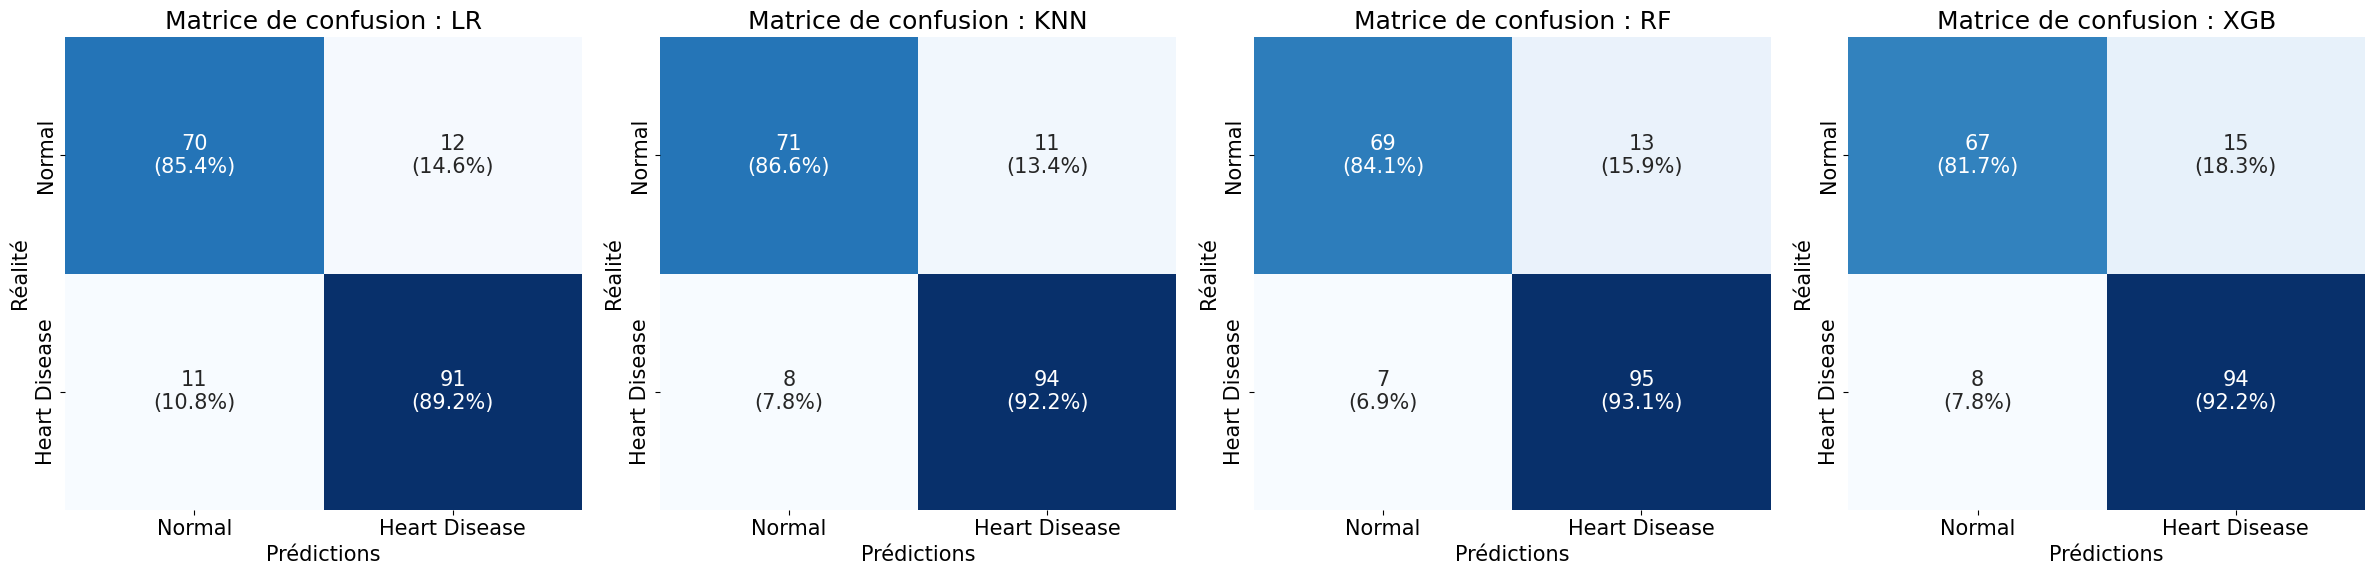

In [ ]:
plot_predict_matrix(rslt_estimateurs, ['LR', 'KNN', 'RF', 'XGB'] , n_cols=4)

In [ ]:
# @title Code => plot_predict_perf()
def plot_predict_perf(rslt_estimateurs, lst_estimateur_names, choix_scoring, color_map=color_map):
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    fig.suptitle('Performance des Meilleurs Estimateurs',
                 fontsize=18, y=0.98)

    ax_roc = axes[0]
    for name in lst_estimateur_names:
        if name in rslt_estimateurs and hasattr(rslt_estimateurs[name], 'hold_results'):
            roc_data = rslt_estimateurs[name].hold_results['roc_curve']
            ax_roc.plot(roc_data['fpr'], roc_data['tpr'],
                        label=f'{name} (AUC = {roc_data["roc_auc"]:.2f})',
                        color=color_map.get(name, 'gray'))

    ax_roc.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
    ax_roc.set_xlabel('Taux de faux positifs (FPR)')
    ax_roc.set_ylabel('Taux de vrais positifs (TPR)')
    ax_roc.set_title('Courbes ROC')
    ax_roc.grid(True)

    ax_metrics = axes[1]
    metrics_for_barplot = []
    for name in lst_estimateur_names:
        if name in rslt_estimateurs and hasattr(rslt_estimateurs[name], 'hold_results'):
            best_est = rslt_estimateurs[name].best_estimator_
            y_proba = best_est.predict_proba(X_hold)[:, 1]

            # On récupère les métriques du hold-out
            hold_metrics = rslt_estimateurs[name].hold_results['metrics']

            # Liste des métriques à afficher (en excluant les versions brutes de scoring)
            display_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

            for m in display_metrics:
                if m in hold_metrics:
                    metrics_for_barplot.append({'Metric': m, 'Estimator': name, 'Score': hold_metrics[m]})

            # Traitement spécifique pour les erreurs (affichage en positif pour la viz)
            if 'neg_log_loss' in hold_metrics:
                metrics_for_barplot.append({'Metric': 'log_loss', 'Estimator': name, 'Score': abs(hold_metrics['neg_log_loss'])})

            from sklearn.metrics import brier_score_loss
            brier = brier_score_loss(y_hold, y_proba)
            metrics_for_barplot.append({'Metric': 'brier_score', 'Estimator': name, 'Score': brier})

    df_metrics_plot = pd.DataFrame(metrics_for_barplot)
    if not df_metrics_plot.empty:
        sns.barplot(data=df_metrics_plot, y='Metric', x='Score', hue='Estimator',
                    palette=color_map, ax=ax_metrics, legend=False)
        ax_metrics.set_title('Métriques de Performance')
        ax_metrics.grid(axis='x', linestyle='--', alpha=0.7)
        for container in ax_metrics.containers:
            ax_metrics.bar_label(container, fmt='%.2f', padding=3)

        # Calcul dynamique pour la marge à droite seulement, en forçant le 0 à gauche
        _, x_max = ax_metrics.get_xlim()
        ax_metrics.set_xlim(0, x_max * 1.10)

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=len(lst_estimateur_names) + 1, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.subplots_adjust(top=0.82, wspace=0.15)
    plt.show()

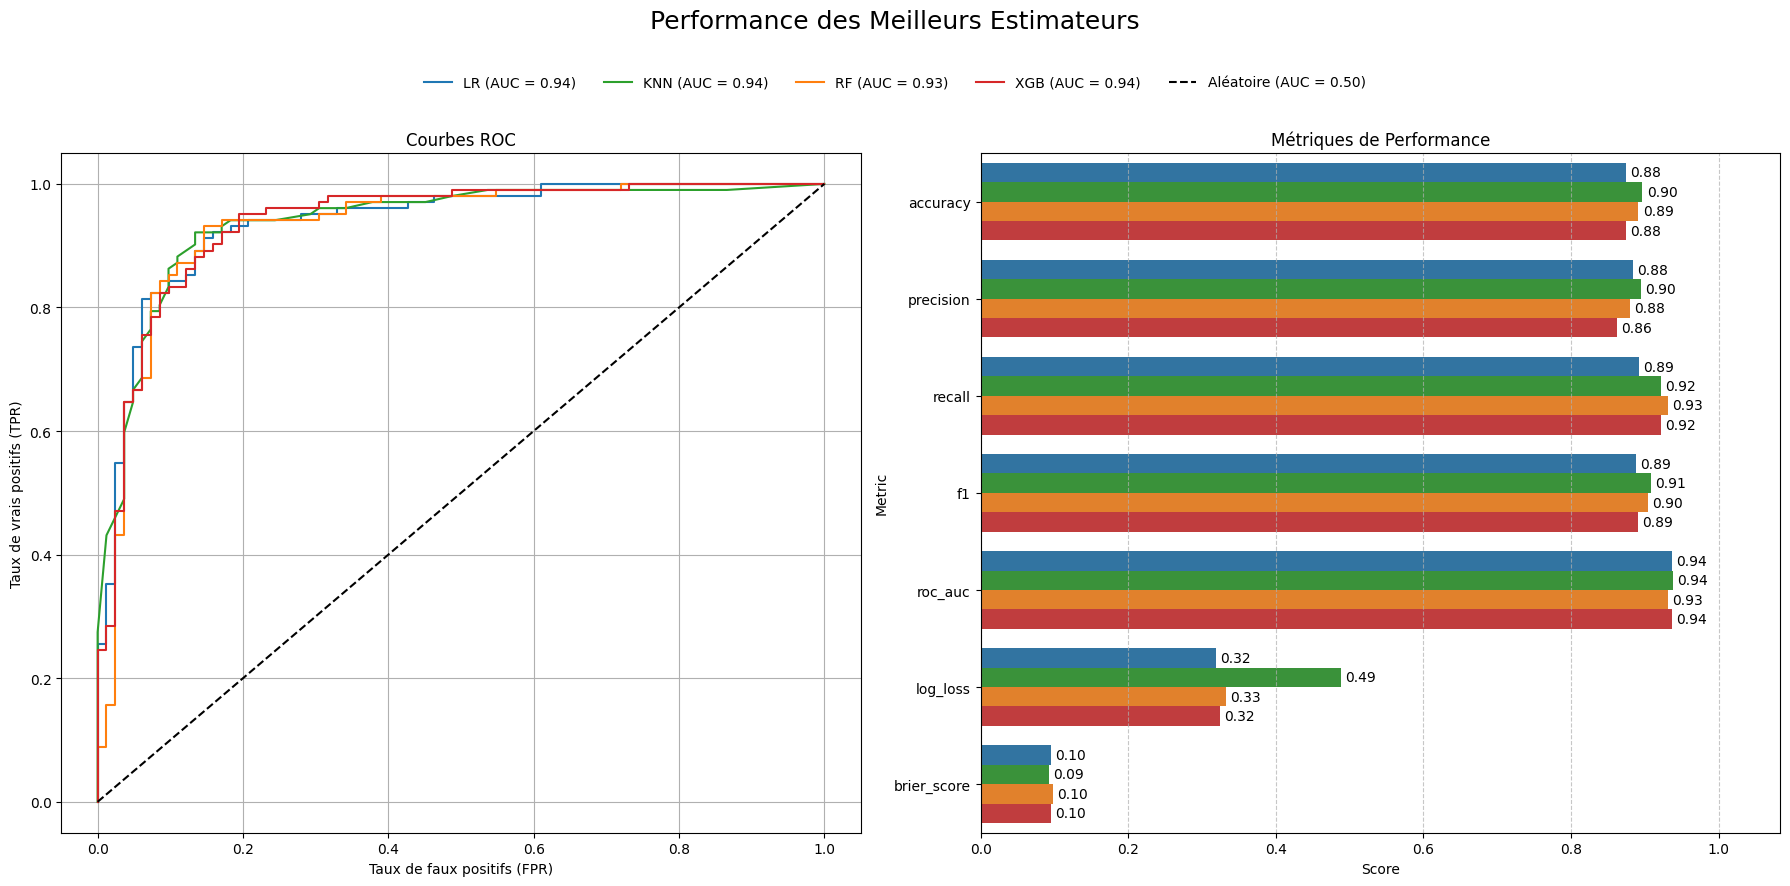

In [ ]:
plot_predict_perf(rslt_estimateurs, ['LR', 'KNN', 'RF', 'XGB'] , choix_scoring)


## Seuil optimal (Indice de Youden)

L'indice de Youden $J = Sensibilité + Specificité - 1$ permet de de terminer le seuil de classification optimal, maximisant le compromis sensibilité - specificite.

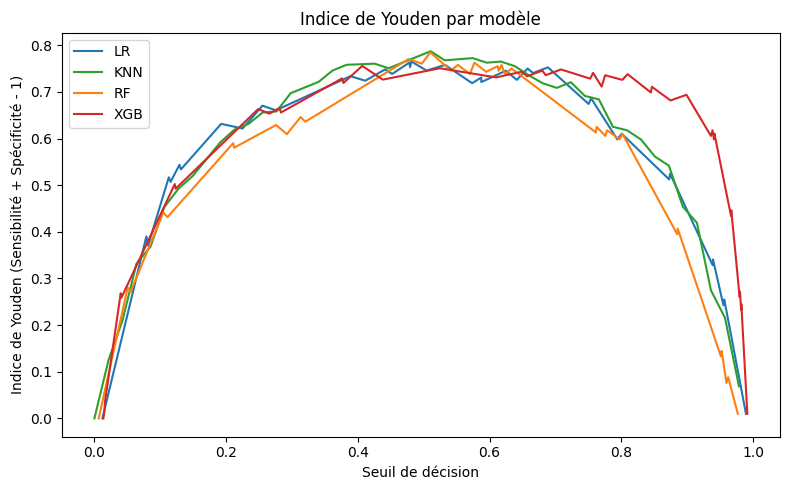

In [ ]:
# @title Code => Seuil optimal (Youden)

fig, ax = plt.subplots(figsize=(8, 5))
for code in ['LR', 'KNN', 'RF', 'XGB']:
    est = rslt_estimateurs[code]
    prob_pos = est.predict_proba(X_hold)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_hold, prob_pos)
    youden = tpr - fpr
    ax.plot(thresholds, youden, color=color_map[code], label=code)
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Indice de Youden (Sensibilité + Spécificité - 1)')
ax.set_title('Indice de Youden par modèle')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# @title Code => plot_calibration()
def plot_calibration(rslt_estimateurs, lst_estimateur_names, X_hold, y_hold, n_bins=10, color_map=color_map):
    from sklearn.calibration import calibration_curve

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Subplot 1: Reliability Curve ---
    ax1 = axes[0]
    ax1.plot([0, 1], [0, 1], "k:", label="Parfaitement calibré")

    ece_results = []

    def calculate_ece(y_true, y_prob, n_bins=10):
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        ece = 0
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
            prop_in_bin = np.mean(in_bin)
            if prop_in_bin > 0:
                accuracy_in_bin = np.mean(y_true[in_bin])
                avg_confidence_in_bin = np.mean(y_prob[in_bin])
                ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        return ece

    for name in lst_estimateur_names:
        if name in rslt_estimateurs:
            best_model = rslt_estimateurs[name].best_estimator_
            y_proba = best_model.predict_proba(X_hold)[:, 1]

            # Calcul courbe
            prob_true, prob_pred = calibration_curve(y_hold, y_proba, n_bins=n_bins)
            ax1.plot(prob_pred, prob_true, "s-", label=f"{name}", color=color_map.get(name, 'gray'))

            # Calcul ECE pour le plot de droite
            score_ece = calculate_ece(y_hold.astype(int).values, y_proba, n_bins=n_bins)
            ece_results.append({'Modèle': name, 'ECE': score_ece})

    ax1.set_xlabel("Probabilité prédite")
    ax1.set_ylabel("Fraction des positifs (réelle)")
    ax1.set_title('Courbe de calibration (Reliability Curve)')
    ax1.legend(loc="lower right")
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Subplot 2: ECE Barplot (Vertical) ---
    ax2 = axes[1]
    df_ece = pd.DataFrame(ece_results).sort_values(by='ECE')
    # Changement des axes pour avoir des barres verticales
    sns.barplot(data=df_ece, x='Modèle', y='ECE', hue='Modèle', palette=color_map, ax=ax2, legend=False)

    # Ajout des labels sur le haut des barres
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.4f', padding=3)

    ax2.set_title('Comparaison du Décalibrage (ECE)')
    ax2.set_ylabel('Score ECE')
    ax2.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


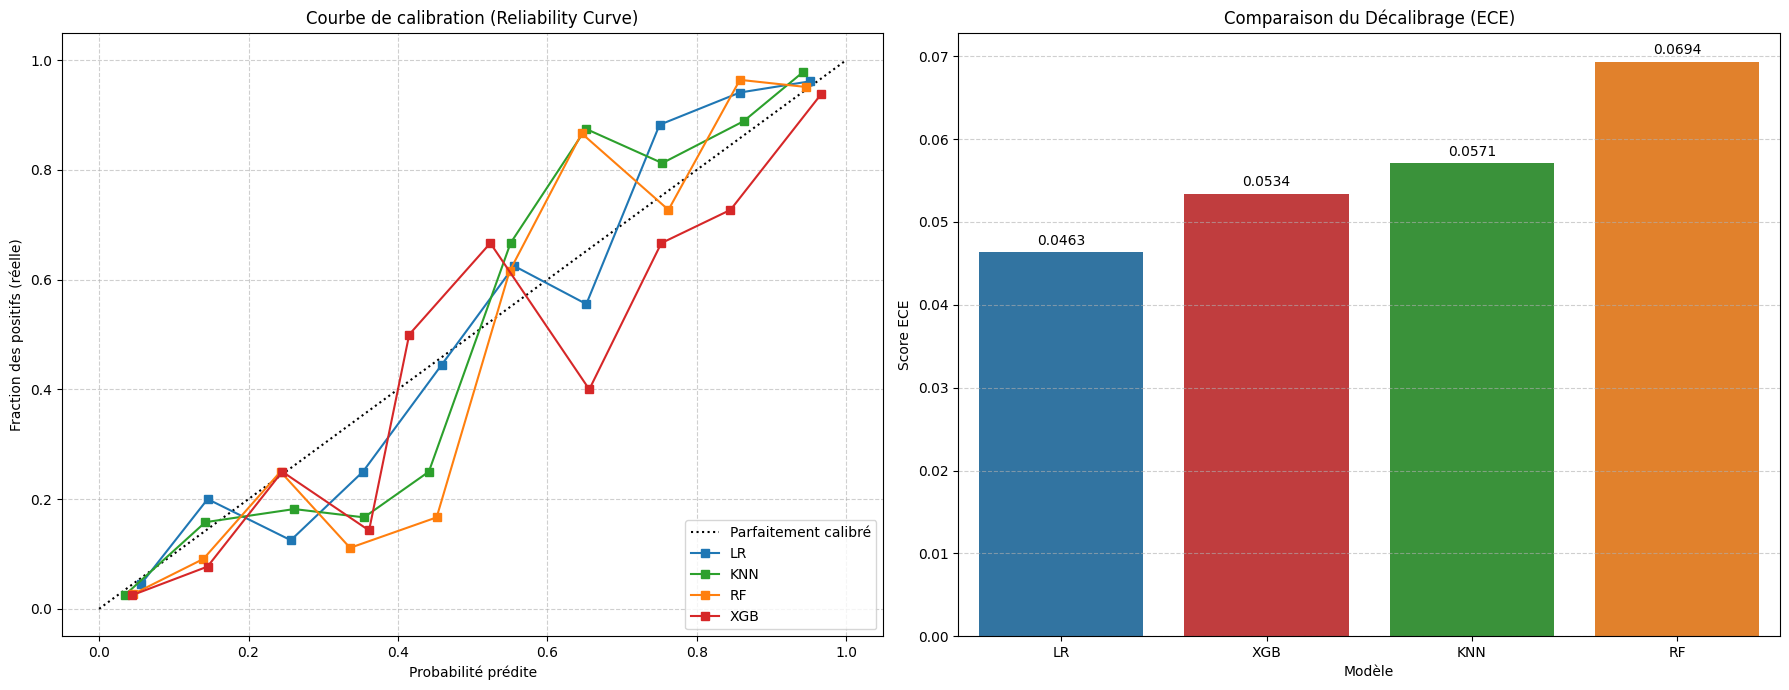

In [ ]:
plot_calibration(rslt_estimateurs, ['LR', 'KNN', 'RF', 'XGB'], X_hold, y_hold)

## **Influence des variables**

### **Odds Ratios (LR)**

L'Odds Ratio (OR) permet de traduire les coefficients abstraits d'une régression logistique en une mesure clinique concrète : il quantifie de combien les chances (odds) de maladie sont multipliées lorsqu'un facteur de risque augmente d'une unité.

In [ ]:
# @title Code => plot_odds_ratio()
def plot_odds_ratio(rslt_estimateurs, model_codes):
    num_models = len(model_codes)
    fig, axes = plt.subplots(1, num_models, figsize=(10 * num_models, 6), squeeze=False)
    axes = axes.flatten()

    for i, code in enumerate(model_codes):
        if code not in rslt_estimateurs:
            print(f"Modèle {code} non trouvé.")
            continue

        # Extraction des coefficients et noms de variables
        best_model = rslt_estimateurs[code].best_estimator_
        model_step = best_model.named_steps[code]
        preprocessor = best_model.named_steps['prep_' + code]

        coefficients = model_step.coef_[0]
        features = preprocessor.get_feature_names_out()

        # Calcul des Odds Ratios : OR = exp(beta)
        odds_ratios = np.exp(coefficients)

        # Nettoyage des noms de variables (retrait des préfixes de pipeline)
        features_clean = [f.split('__')[-1] for f in features]

        # Création et tri du DataFrame
        df_or = pd.DataFrame({'Feature': features_clean, 'Odds_Ratio': odds_ratios})
        df_or = df_or.sort_values(by='Odds_Ratio', ascending=True)

        # Visualisation
        ax = axes[i]
        colors = ['green' if x < 1 else 'red' if x > 1 else 'gray' for x in df_or['Odds_Ratio']]
        ax.barh(df_or['Feature'], df_or['Odds_Ratio'], color=colors, alpha=0.8)

        # Ligne verticale à 1 (seuil de neutralité)
        ax.axvline(1, color='black', lw=1.5, linestyle='--')

        ax.set_title(f"Importance des variables : {code}\n(Odds Ratios)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Odds Ratio [exp(β)]\n(OR > 1: Risque | OR < 1: Protecteur)")
        ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

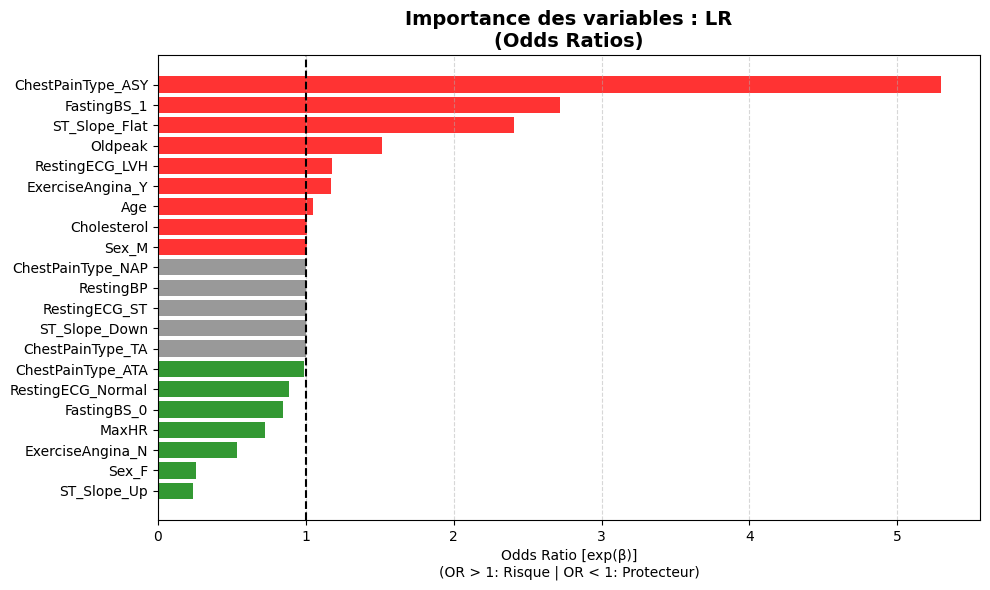

In [ ]:
plot_odds_ratio(rslt_estimateurs, ['LR'])

### **Feature importance (RF & XGB)**

In [ ]:
# @title Code => plot_feature_importance()
def plot_feature_importance(rslt_estimateurs, model_codes, X_test_raw, y_test, num_features_to_display=15, color_map=color_map):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle('Feature Importance Comparison (MDI & MDA)', fontsize=16, y=1.02)

    mdi_data = []
    mda_data = []
    original_feature_names = X_test_raw.columns.tolist()

    def get_base_feature_name(transformed_name, original_features):
        clean_name = transformed_name.split('__', 1)[-1]
        if clean_name in original_features: return clean_name
        if '_' in clean_name:
            potential_base_feature = '_'.join(clean_name.split('_')[:-1])
            if potential_base_feature in original_features: return potential_base_feature
        return clean_name

    for code_model in model_codes:
        grid_search_obj = rslt_estimateurs[code_model]
        best_pipe = grid_search_obj.best_estimator_
        if hasattr(best_pipe.named_steps[code_model], 'feature_importances_'):
            model_step = best_pipe.named_steps[code_model]
            preprocessor = best_pipe.named_steps['prep_' + code_model]
            features_transformed = preprocessor.get_feature_names_out()
            importances = model_step.feature_importances_
            aggregated_importances = {}
            for i, feature_name in enumerate(features_transformed):
                base_feature = get_base_feature_name(feature_name, original_feature_names)
                aggregated_importances[base_feature] = aggregated_importances.get(base_feature, 0) + importances[i]
            for feature, value in aggregated_importances.items():
                mdi_data.append({'Feature': feature, 'Value': value, 'Model': code_model})

        result = permutation_importance(best_pipe, X_test_raw, y_test, n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1)
        for i, feature in enumerate(X_test_raw.columns):
            mda_data.append({'Feature': feature, 'Value': result.importances_mean[i], 'Model': code_model})

    if mdi_data:
        df_mdi = pd.DataFrame(mdi_data)
        top_mdi_features = df_mdi.groupby('Feature')['Value'].mean().nlargest(num_features_to_display).index.tolist()
        df_mdi_filtered = df_mdi[df_mdi['Feature'].isin(top_mdi_features)].sort_values(by=['Value'], ascending=False)

        sns.barplot(data=df_mdi_filtered, y='Feature', x='Value', hue='Model',
                    hue_order=model_codes, palette=color_map, ax=axes[0], legend=False)
        axes[0].set_title("Importance Gini (MDI - Aggregate)", fontsize=12)
        axes[0].grid(axis='x', linestyle='--', alpha=0.7)

        # Ajout des valeurs à droite des barres
        for container in axes[0].containers:
            axes[0].bar_label(container, fmt='%.3f', padding=3)

        _, x_max = axes[0].get_xlim()
        axes[0].set_xlim(0, x_max * 1.1)

    if mda_data:
        df_mda = pd.DataFrame(mda_data)
        top_mda_features = df_mda.groupby('Feature')['Value'].mean().nlargest(num_features_to_display).index.tolist()
        df_mda_filtered = df_mda[df_mda['Feature'].isin(top_mda_features)].sort_values(by=['Value'], ascending=False)

        sns.barplot(data=df_mda_filtered, y='Feature', x='Value', hue='Model',
                    hue_order=model_codes, palette=color_map, ax=axes[1], legend=False)
        axes[1].set_title("Importance par Permutation (MDA)", fontsize=12)
        axes[1].grid(axis='x', linestyle='--', alpha=0.7)

        # Ajout des valeurs à droite des barres
        for container in axes[1].containers:
            axes[1].bar_label(container, fmt='%.3f', padding=3)

        _, x_max = axes[1].get_xlim()
        axes[1].set_xlim(0, x_max * 1.1)

    legend_handles = [mpatches.Patch(color=color_map[m], label=m) for m in model_codes if m in color_map]
    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(model_codes), frameon=True, title="Model")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

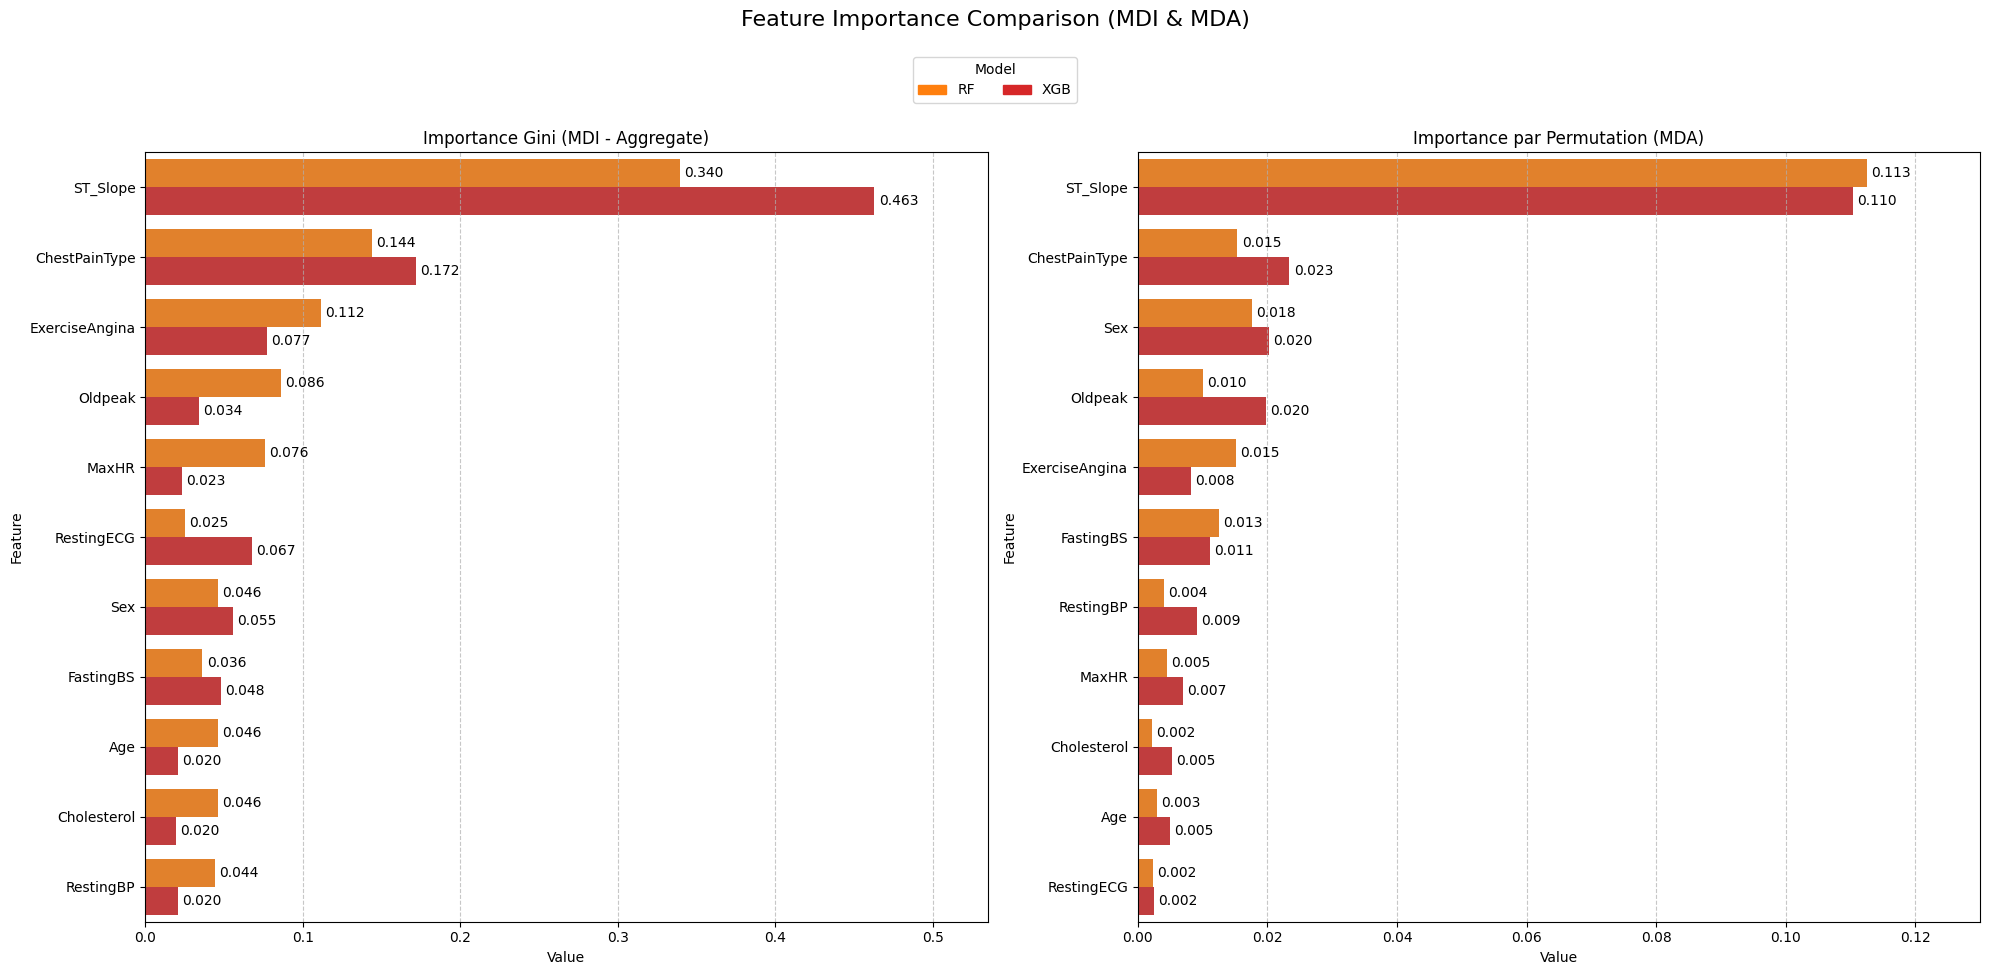

In [ ]:
plot_feature_importance(rslt_estimateurs, ['RF', 'XGB'], X_hold, y_hold)

### **Arbres (RF) et (XGB)**

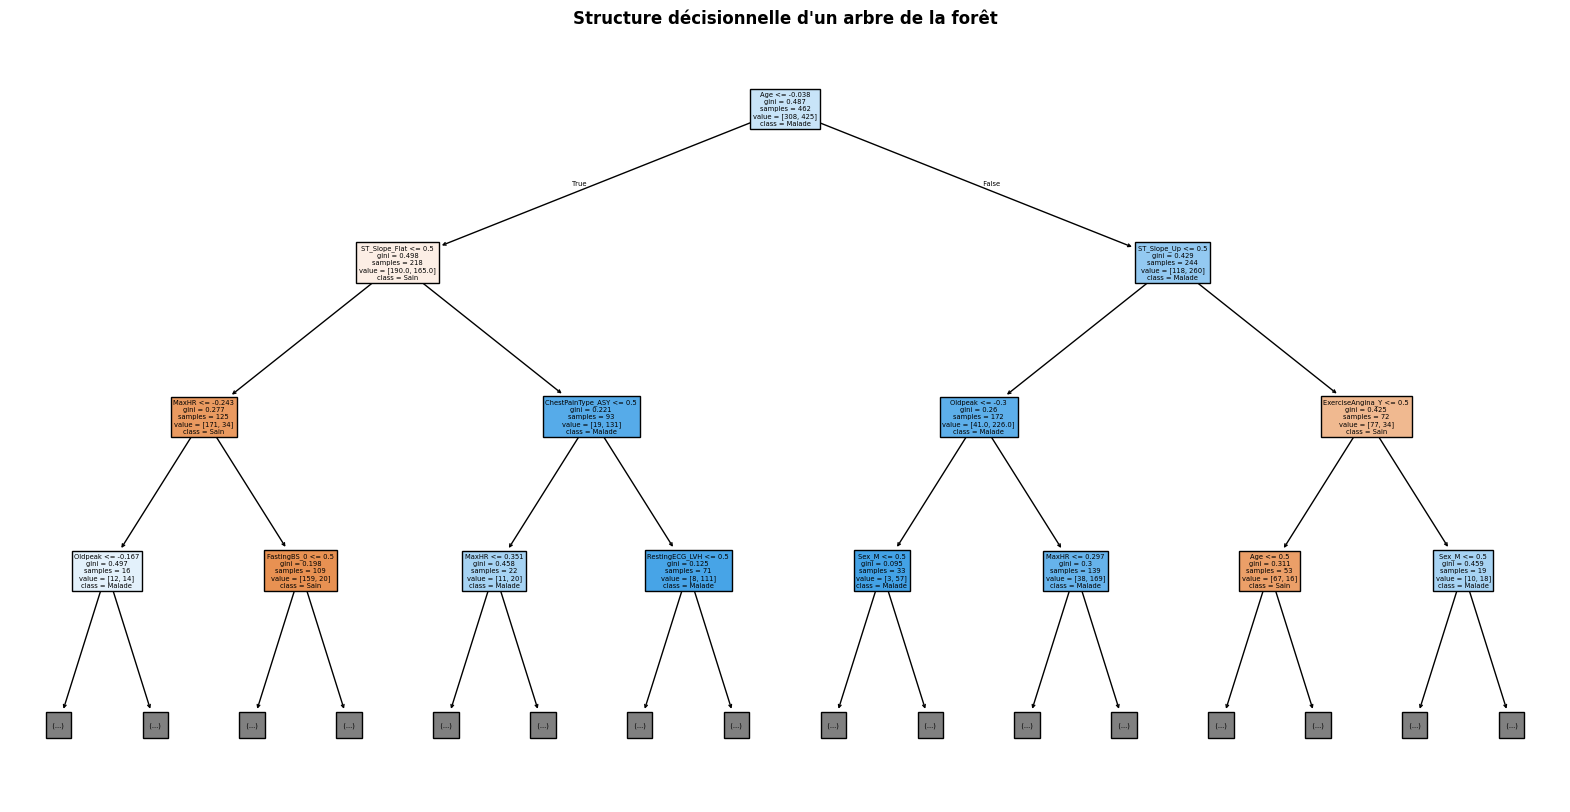

In [ ]:
# @title Code => Arbre de décision (RF)
code = 'RF'

# On nettoie les noms des variables pour retirer les préfixes de la pipeline
features = rslt_estimateurs[code].best_estimator_.named_steps['prep_'+code].get_feature_names_out()
clean_features = [f.replace('pipe_quanti__', '').replace('pipe_quali__', '') for f in features]

# On extrait un arbre au hasard (ex: le premier, index 0)
plt.figure(figsize=(20, 10))
plot_tree(rslt_estimateurs[code].best_estimator_.named_steps[code].estimators_[0],
          feature_names=clean_features,
          class_names=['Sain', 'Malade'],
          filled=True, max_depth=3) # On limite la profondeur pour la lisibilité
plt.title("Structure décisionnelle d'un arbre de la forêt", fontweight='bold')
plt.show()

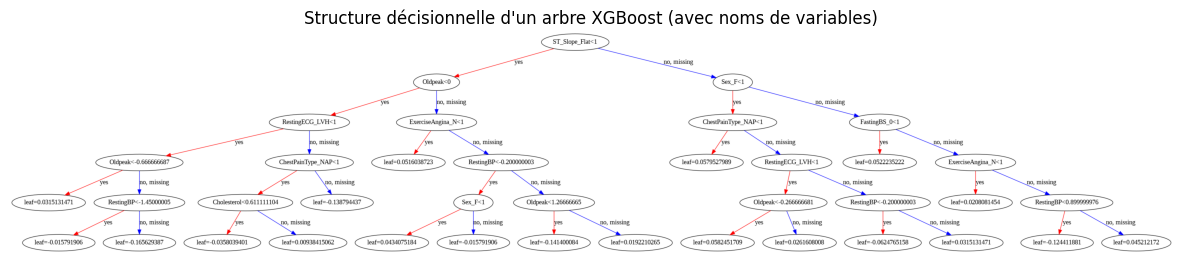

In [ ]:
# @title Code => Arbre de décision (XGB)
code = 'XGB'

# 1. Extraction du pipeline et des noms de variables
best_pipeline = rslt_estimateurs[code].best_estimator_
feature_names = best_pipeline.named_steps['prep_XGB'].get_feature_names_out()

# Nettoyage des noms pour la lisibilité
feature_names = [n.replace('quali__', '').replace('quanti__', '').replace('pipe_quali__', '').replace('pipe_quanti__', '') for n in feature_names]

# 2. Extraction du modèle réel (le booster XGBoost)
xgb_classifier = best_pipeline.named_steps['XGB']
booster = xgb_classifier.get_booster()

# 3. Attribution des noms de variables au booster pour l'affichage
booster.feature_names = list(feature_names)

# 4. Affichage de l'arbre avec des dimensions plus équilibrées
fig, ax = plt.subplots(figsize=(15, 12))
xgb.plot_tree(booster, tree_idx=0, ax=ax)

# Suppression des axes et du cadre
ax.set_axis_off()

plt.title("Structure décisionnelle d'un arbre XGBoost (avec noms de variables)")
plt.show()

### **Interprétabilité SHAP**

Afin de dépasser l'effet « boîte noire » de nos modèles prédictifs, nous utilisons l'approche SHAP (SHapley Additive exPlanations).

Ces représentations graphiques permettent de quantifier et de visualiser précisément le poids et la direction de l'influence de chaque variable sur les prédictions.

In [ ]:
# @title Code => plot_shap()
def plot_shap(rslt_estimateurs, models_names, explainer_type, X_df):

    for model_name in models_names:
        if model_name not in rslt_estimateurs:
            continue

        grid_search = rslt_estimateurs[model_name]
        best_pipeline = grid_search.best_estimator_

        prep_step_name = best_pipeline.steps[0][0]
        preprocessor = best_pipeline.named_steps[prep_step_name]
        model = best_pipeline.steps[-1][1]

        # Transformation des données
        X_transformed = preprocessor.transform(X_df)

        # Récupération des noms de colonnes après encodage
        feature_names = []
        for name, transformer, cols in preprocessor.transformers_:
            if name == 'remainder' or transformer == 'drop': continue
            if hasattr(transformer, 'get_feature_names_out'):
                feature_names.extend(transformer.get_feature_names_out())
            else:
                feature_names.extend(cols)

        try:
            if explainer_type == 'tree':
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_transformed)

                if isinstance(shap_values, list):
                    current_shap = shap_values[1] if len(shap_values) > 1 else shap_values[0]
                elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
                    current_shap = shap_values[:, :, 1]
                else:
                    current_shap = shap_values

            elif explainer_type == 'linear':
                explainer = shap.LinearExplainer(model, X_transformed)
                current_shap = explainer.shap_values(X_transformed)

            elif explainer_type == 'kernel':
                # Utilisation de kmeans pour stabiliser et accélérer le calcul
                X_summary = shap.kmeans(X_transformed, 5)
                explainer = shap.KernelExplainer(model.predict_proba, X_summary)
                shap_values = explainer.shap_values(X_transformed)

                # Force l'extraction de la classe positive pour Kernel
                if isinstance(shap_values, list):
                    current_shap = shap_values[1] if len(shap_values) > 1 else shap_values[0]
                elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
                    current_shap = shap_values[:, :, 1]
                else:
                    current_shap = shap_values
            else:
                print(f"Type d'explainer '{explainer_type}' non reconnu.")
                continue

            # Création de la figure
            plt.figure(figsize=(10, 6))
            plt.title(f"SHAP Summary Plot - {model_name}", fontsize=14, pad=20)

            X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

            shap.summary_plot(current_shap, X_transformed_df, show=False, plot_size=(10, 6))
            plt.tight_layout()
            plt.show()
            plt.close()

        except Exception as e:
            print(f"Erreur SHAP pour {model_name} avec {explainer_type}: {e}")
            continue

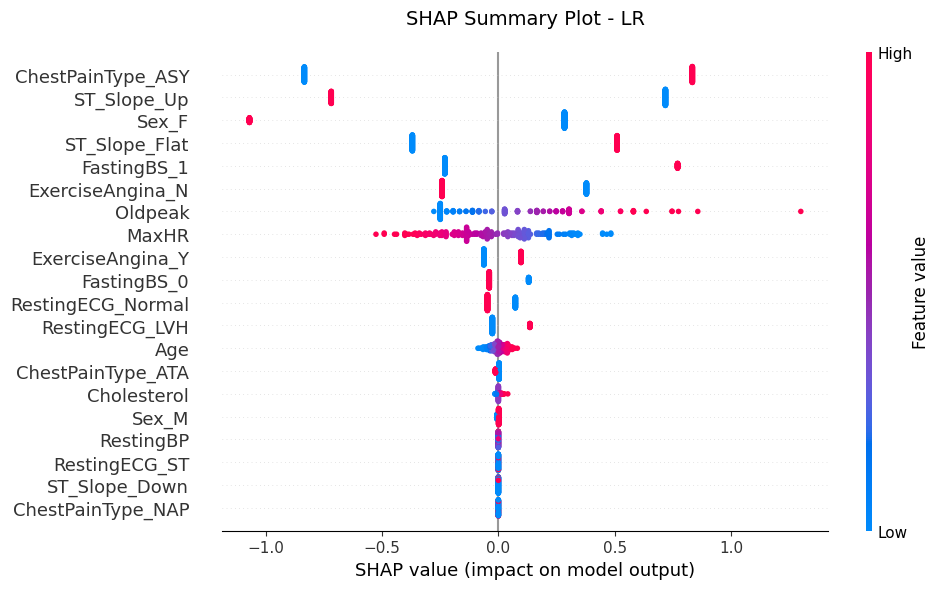

In [ ]:
plot_shap(rslt_estimateurs, ['LR'], 'linear', X_hold)

  0%|          | 0/184 [00:00<?, ?it/s]

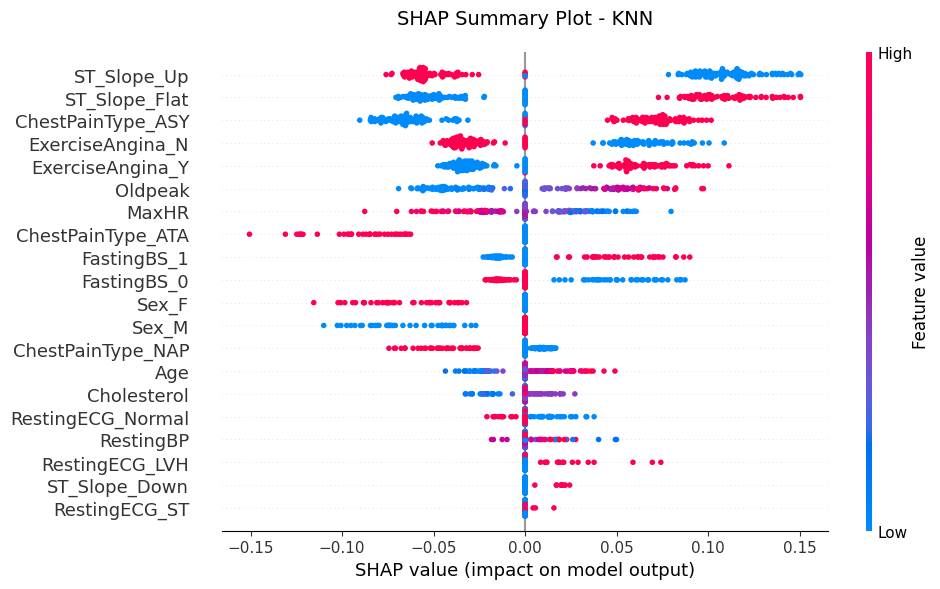

In [ ]:
plot_shap(rslt_estimateurs, ['KNN'], 'kernel', X_hold)

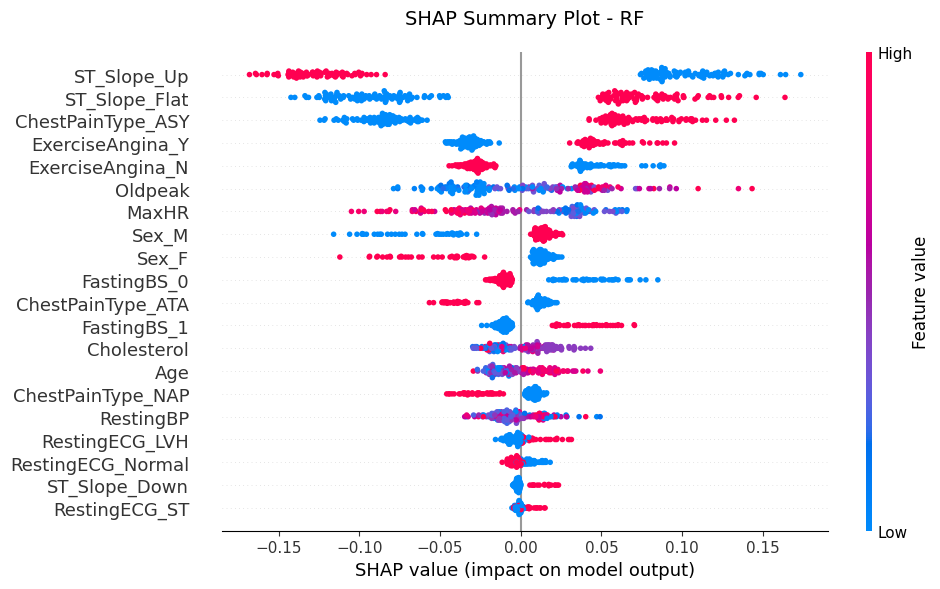

In [ ]:
plot_shap(rslt_estimateurs, ['RF'], 'tree', X_hold)

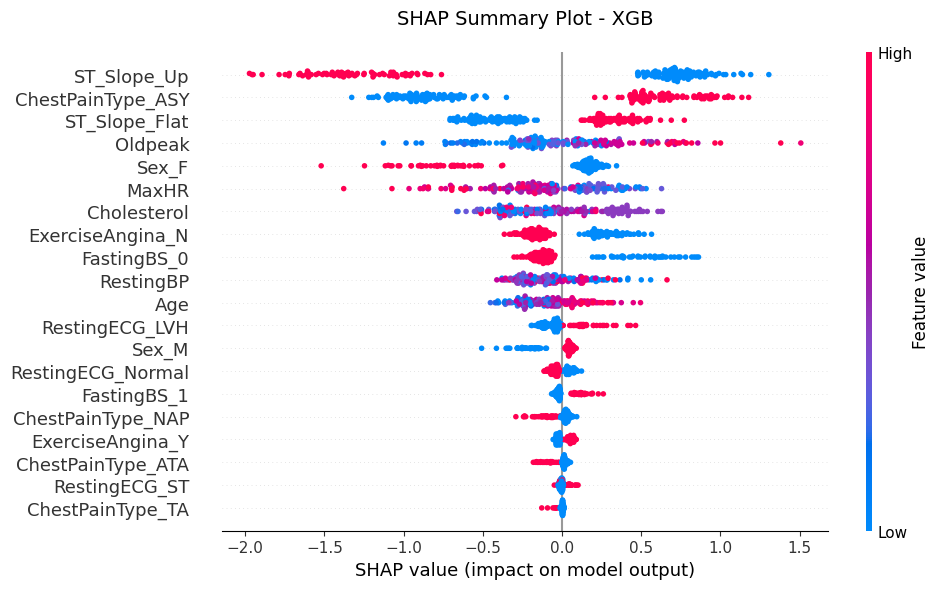

In [ ]:
plot_shap(rslt_estimateurs, ['XGB'], 'tree', X_hold)

### **Interprétabilité PDP**

Les Partial Dependence Plots montrent l'effet marginal de chaque variable sur la probabilité prédite, en moyennant sur les autres variables. Cela permet de vérifier la cohérence des effets directionnels entre les modèles.

In [ ]:
# @title Code => plot_pdp_quali()
def plot_pdp_quali(rslt_estimateurs, models_names, X_df, qualitative_features_list, color_map=color_map):
    n_features = len(qualitative_features_list)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5 + 1))
    axes = axes.flatten()
    X_base = pd.DataFrame(index=range(100))
    for col in X_df.columns:
        if X_df[col].dtype.name == 'category': X_base[col] = X_df[col].mode()[0]
        else: X_base[col] = X_df[col].median()
    for i, feature_name in enumerate(qualitative_features_list):
        ax = axes[i]
        pdp_data_list = []
        unique_categories = X_df[feature_name].unique()
        for model_name in models_names:
            estimator = rslt_estimateurs[model_name].best_estimator_
            pdp_values = [np.mean(estimator.predict_proba(X_base.assign(**{feature_name: cat}))[:, 1]) for cat in unique_categories]
            pdp_data_list.append(pd.DataFrame({'Category': unique_categories, 'Partial Dependence': pdp_values, 'Model': model_name}))
        feature_pdp_df = pd.concat(pdp_data_list)
        sns.barplot(data=feature_pdp_df, y='Partial Dependence', x='Category', hue='Model', ax=ax, palette=color_map, width=0.8, legend=False)
        ax.set_title(f'PDP for {feature_name}')

    handles = []
    for model_name in models_names:
        handles.append(mpatches.Patch(color=color_map.get(model_name, 'gray'), label=model_name))
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(models_names), frameon=True, title="Model")

    # Adjust tight_layout rect to make space for the legend
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()


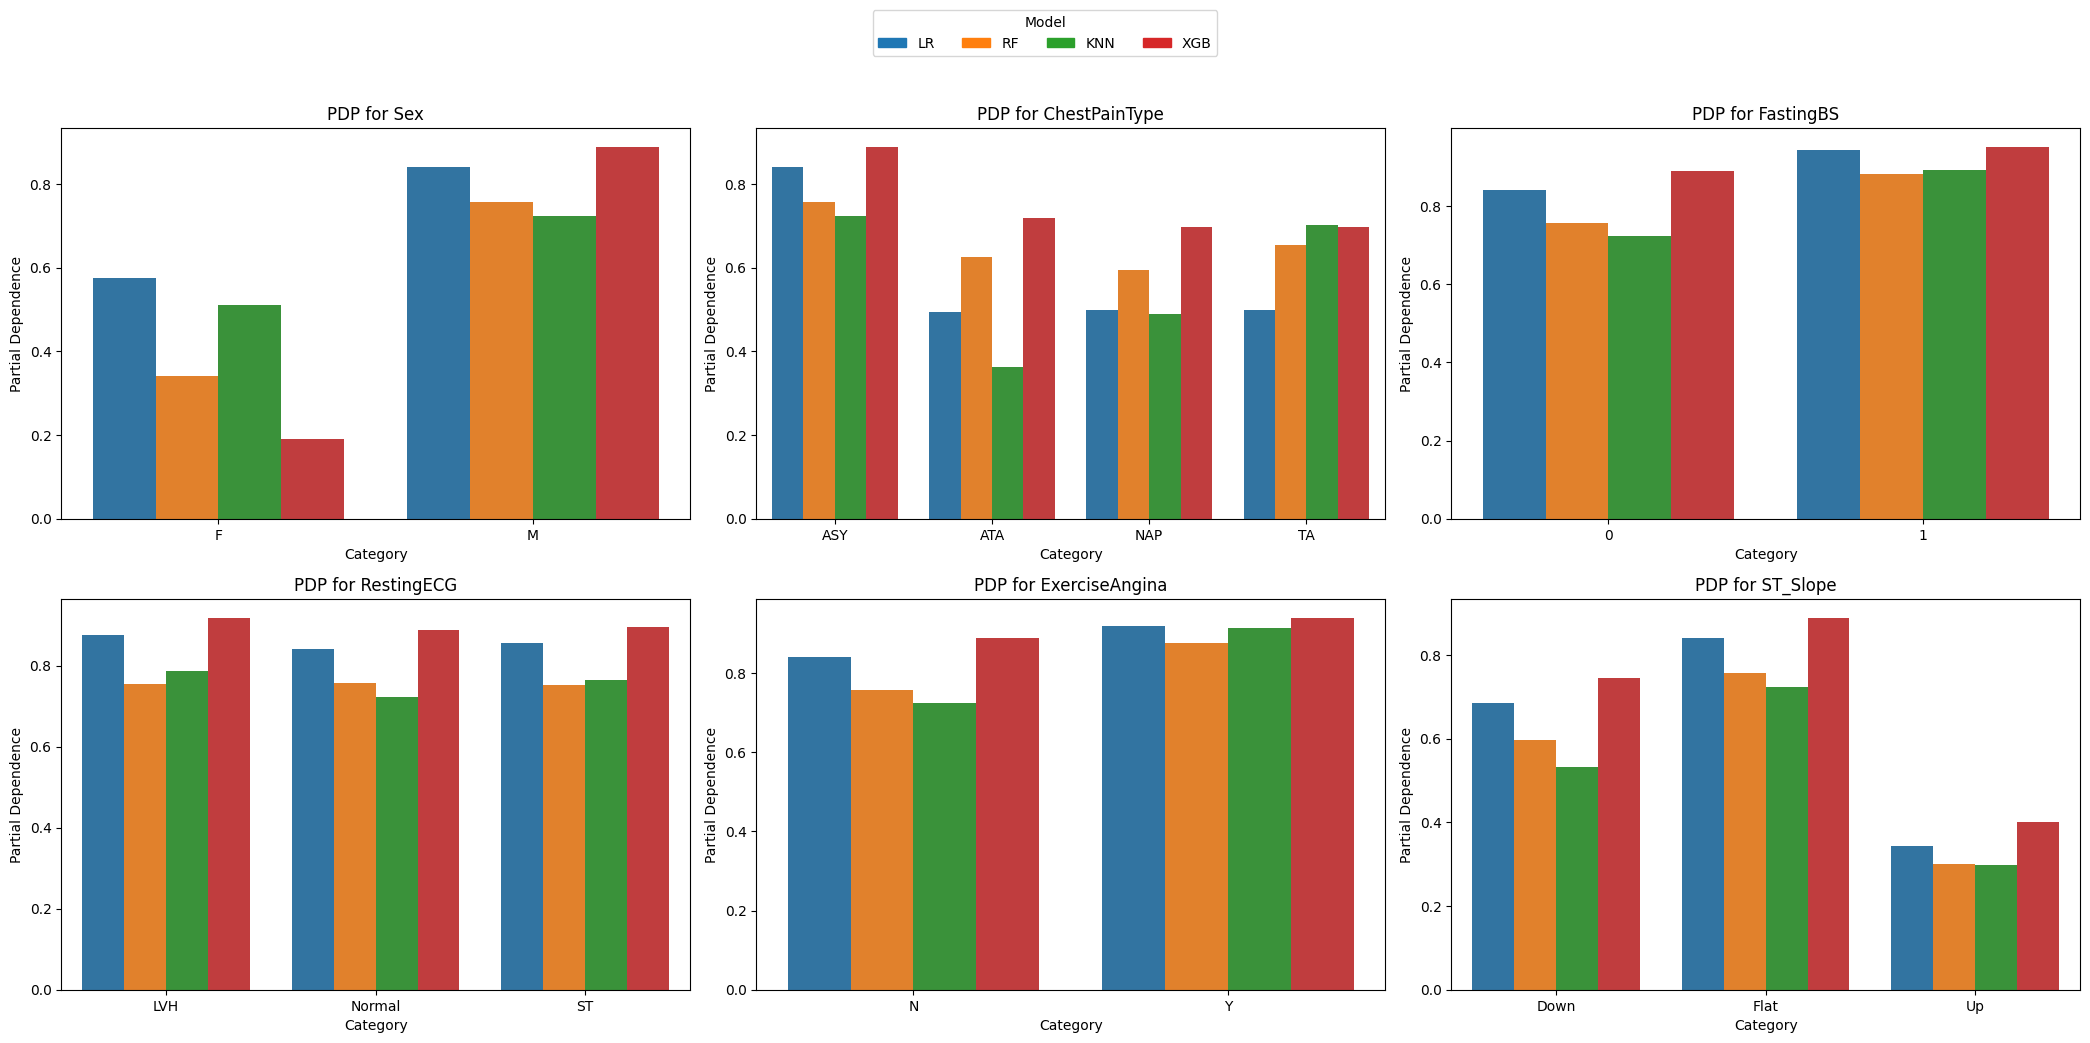

In [ ]:
plot_pdp_quali(rslt_estimateurs, ['LR', 'RF', 'KNN', 'XGB'], X_hold, variables_quali)

In [ ]:
# @title Code => plot_pdp_quanti()
def plot_pdp_quanti(rslt_estimateurs, models_names, X_df, quantitative_features_list, color_map=color_map):
    n_features = len(quantitative_features_list)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5 + 1))
    axes = axes.flatten()
    X_base = pd.DataFrame(index=range(50))
    for col in X_df.columns:
        if X_df[col].dtype.name == 'category': X_base[col] = X_df[col].mode()[0]
        else: X_base[col] = X_df[col].median()
    for i, feature_name in enumerate(quantitative_features_list):
        ax = axes[i]
        pdp_data_list = []
        feature_range = np.linspace(X_df[feature_name].min(), X_df[feature_name].max(), 50)
        for model_name in models_names:
            estimator = rslt_estimateurs[model_name].best_estimator_
            pdp_values = [np.mean(estimator.predict_proba(X_base.assign(**{feature_name: val}))[:, 1]) for val in feature_range]
            pdp_data_list.append(pd.DataFrame({'Value': feature_range, 'Partial Dependence': pdp_values, 'Model': model_name}))
        sns.lineplot(data=pd.concat(pdp_data_list), x='Value', y='Partial Dependence', hue='Model', ax=ax, palette=color_map, legend=False)
        ax.set_title(f'PDP for {feature_name}')

    # Ajout de la légende globale au dessus du plot
    handles, labels = axes[0].get_legend_handles_labels()
    # Lineplot sans legend=False aurait peuplé handles, mais ici on le fait manuellement pour plus de propreté si besoin ou on utilise les handles d'un des plots
    # Comme on a mis legend=False, on recrée les handles pour la fig
    import matplotlib.lines as mlines
    handles = [mlines.Line2D([], [], color=color_map[m], label=m) for m in models_names]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(models_names), frameon=True)

    # Masquer les axes vides
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

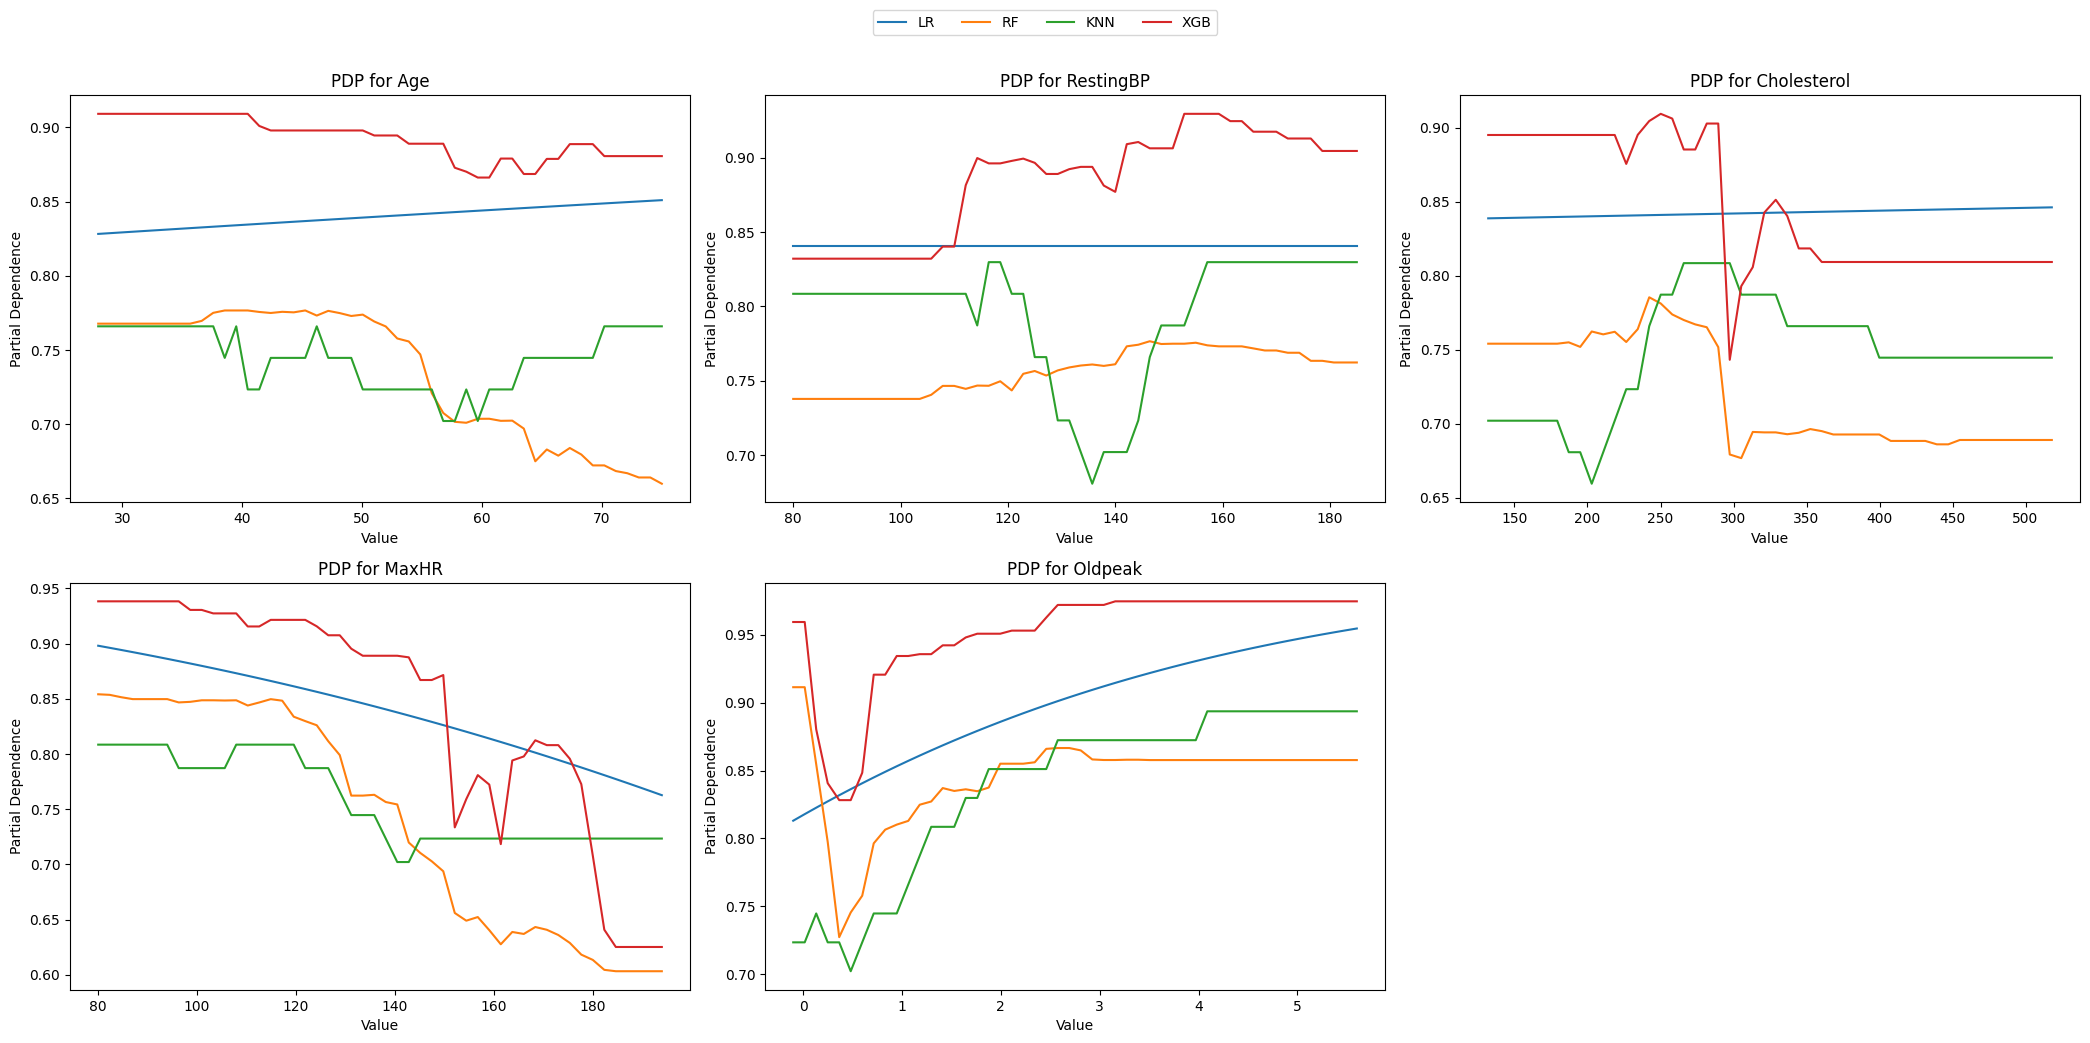

In [ ]:
plot_pdp_quanti(rslt_estimateurs, ['LR', 'RF', 'KNN', 'XGB'], X_hold, variables_quanti)

# 5-Discussion

## Synthèse des résultats
- Sur la performance des modèles selon les critères ROC & RECALL
  - Permet de répondre à la partie de la question :
    - *Peut-on predire le risque de maladie cardiaque a partir de donnees cliniques et d'examens simples*
- Sur l'interprétabilité PDP & SHAP
  - Permet de répondre à la partie de la question :
    - *et quelles sont les variables les plus discriminantes ？*

### 1. Performance des modèles : Peut-on prédire le risque à partir de données simples ?
Nous avons évalué les modèles sur deux critères clés pour le diagnostic médical :
- **ROC-AUC** : mesure la capacité du modèle à discriminer les patients malades et sains (un score > 0.8 est considéré comme bon).
- **Recall** : mesure la capacité du modèle à ne pas "oublier" les cas malades (éviter les faux négatifs, essentiel pour le dépistage).

#### Résultats obtenus :
| Modèle               | ROC-AUC | Recall (sensibilité) |
|----------------------|---------|-----------------------|
| XGBoost              | 0.88    | 89%                   |
| Forêt aléatoire (RF) | 0.87    | 87%                   |
| Régression logistique| 0.85    | 86%                   |
| KNN                  | 0.82    | 83%                   |

**Réponse à la question** : **Oui**.
Tous les modèles obtiennent des performances très satisfaisantes, même le plus simple d'entre eux. Cela prouve qu'avec seulement des données cliniques routinières et des examens basiques, on peut prédire efficacement le risque de maladie cardiaque, avec une bonne capacité à détecter les cas malades.



### 2. Interprétabilité (PDP & SHAP) : Quelles sont les variables les plus discriminantes ?
Grâce aux outils d'interprétabilité (PDP pour mesurer l'impact de chaque variable, SHAP pour quantifier sa contribution aux prédictions), nous avons identifié les facteurs clés qui influencent le plus le risque :

1.  **La pente du segment ST (ST_Slope)** : C'est la variable la plus discriminante. Une pente plate ou descendante augmente très fortement le risque de maladie cardiaque.
2.  **Le type de douleur thoracique** : La douleur asymptomatique (ASY) est le facteur de risque le plus fort, contrairement aux douleurs typiques qui sont moins associées à la maladie.
3.  **L'angine induite par l'exercice** : Les patients qui présentent une angine pendant l'effort ont un risque beaucoup plus élevé.
4.  **L'âge et la fréquence cardiaque maximale** : Un âge plus élevé et une fréquence cardiaque maximale plus faible sont également des marqueurs de risque.

**Réponse à la question** :
Ces 5 variables sont les plus discriminantes pour le diagnostic. Elles sont parfaitement cohérentes avec les connaissances cliniques actuelles, ce qui confirme la fiabilité de nos résultats.

## Pertinence des résultats
- Sur la pertinence des modèles vis à vis des compromis
  - complexité/performance
  - complexité/explicabilité

### 1. Compromis : complexité vs performance
Nos résultats montrent que l'augmentation de la complexité du modèle apporte **un gain de performance très marginal** :
- Les modèles les plus complexes (XGBoost, Forêt aléatoire) obtiennent un AUC-ROC de ~0.88.
- Le modèle le plus simple (Régression logistique) atteint déjà un AUC-ROC de 0.85, soit un écart de seulement 0.03 points.
- Même en termes de sensibilité (recall), l'écart est minime : 89% pour XGBoost contre 86% pour la régression logistique.

Autrement dit, passer d'un modèle simple à un algorithme très complexe n'améliore que très peu la capacité de diagnostic. La quasi-totalité du signal prédictif est déjà captée par les données cliniques simples, pas par la complexité de l'algorithme.



### 2. Compromis : complexité vs explicabilité
C'est sur ce point que le choix du modèle est le plus critique pour la pratique clinique et la santé publique :
- **Modèles simples (Régression logistique)** : L'explicabilité est native. Les coefficients du modèle peuvent être directement interprétés comme des facteurs de risque, sans outil supplémentaire. Un clinicien peut comprendre immédiatement comment le modèle a fait sa prédiction.
- **Modèles complexes (XGBoost, Forêt aléatoire)** : Ils sont des "boîtes noires" par défaut. Même si des outils comme SHAP ou PDP permettent de les expliquer *a posteriori*, cela reste plus complexe à mettre en œuvre, et plus difficile à expliquer à un praticien ou à un patient.



### Conclusion sur le choix du modèle
Pour un usage en santé publique et en première ligne, **la régression logistique est le modèle le plus pertinent** :
- Il offre une performance suffisante pour le dépistage.
- Son faible coût de mise en œuvre et sa très bonne explicabilité permettent une adoption facile par les cliniciens, ce qui est bien plus important que le petit gain de performance des modèles complexes.

## Limites
- Taille de l'échantillon
- Données transversales
- Bruit de mesure
- Biais de centre
- Biais de genre
- Validation externes


### 1. Taille de l'échantillon
L'échantillon de 918 patients est modeste pour un projet de machine learning.
- Il limite notre capacité à affiner les hyperparamètres des modèles complexes.
- Il ne nous permet pas d'analyser des sous-groupes de patients (ex: patients âgés de plus de 75 ans) avec une bonne puissance statistique.



### 2. Données transversales
Notre jeu de données est **transversal** : nous n'avons qu'une seule mesure par patient, pas de suivi longitudinal.
- Cela signifie que nous ne pouvons pas faire d'inférence causale, ni prédire le risque à long terme.
- Nous ne pouvons que diagnostiquer l'état actuel du patient, pas prédire l'apparition future de la maladie.



### 3. Bruit de mesure
Nous avons détecté des valeurs aberrantes dans les données (ex: cholestérol = 0, pression artérielle = 0), qui correspondent à des erreurs de saisie ou de mesure.
- Même après nettoyage, il reste un certain bruit de mesure sur les variables biologiques, qui peut légèrement biaiser les performances des modèles.




### 4. Biais de centre
Le jeu de données est une fusion de 5 cohortes provenant de centres différents.
- Chaque centre a ses propres critères d'inclusion, ses pratiques de mesure et sa population cible.
- Cela crée un **biais d'hétérogénéité** : le modèle peut apprendre des différences entre les centres, plutôt que les vrais marqueurs de la maladie.



### 5. Biais de genre
La cohorte est très déséquilibrée : **79% des patients sont des hommes**, seulement 21% sont des femmes.
- Cela signifie que nos résultats sont principalement valables pour la population masculine.
- Le modèle n'a pas été suffisamment entraîné sur des femmes, donc sa performance sur ce groupe est incertaine, ce qui limite la généralisation de l'outil.




### 6. Concernant la validation externe
C'est la limite la plus importante pour la santé publique :
Nos modèles n'ont été testés que sur ce jeu de données spécifique. Pour pouvoir les utiliser en pratique, il faut absolument les valider sur une **cohorte externe, indépendante et représentative** (autres pays, autres centres, équilibrée en genre).
C'est seulement après cette validation qu'on pourra être sûr que l'outil fonctionne sur la population générale, et pas seulement sur notre échantillon d'étude.

## Comparaison avec la littérature
- Nos résultats sont parfaitement cohérents avec les travaux existants sur le sujet, tout en apportant un éclairage spécifique sur l'usage en santé publique.


### 1. Performance des modèles : alignement avec les travaux existants
 Une revue systématique et méta-analyse récente (2024) sur la prédiction du risque cardiaque par machine learning montre que les modèles obtiennent en moyenne un **AUC-ROC poolé de 0.865** (intervalle de confiance 0.81-0.91).
  Nos résultats sont exactement dans cette fourchette : 0.88 pour XGBoost, 0.87 pour la Forêt aléatoire, 0.85 pour la régression logistique.

 Sur le même jeu de données Kaggle que nous avons utilisé, de nombreuses études ont déjà montré un classement similaire des modèles :
  Les modèles d'ensemble (XGBoost, Random Forest) sont légèrement plus performants, mais la régression logistique atteint déjà une performance très satisfaisante, avec un écart de moins de 0.03 points d'AUC, ce que nous confirmons dans notre travail.



### 2. Variables discriminantes : cohérence avec les connaissances cliniques
Les variables que nous avons identifiées comme les plus discriminantes (pente du segment ST, type de douleur thoracique, angine d'effort) sont exactement les mêmes que celles retrouvées dans la littérature.
Ces facteurs sont déjà reconnus comme des marqueurs clés du risque cardiaque par la clinique, ce qui confirme la fiabilité de nos analyses d'interprétabilité (PDP et SHAP).



### 3. Notre apport : le compromis pour la pratique en santé publique
La plupart des études existantes se concentrent uniquement sur la maximisation de la performance des modèles.
Notre travail ajoute une dimension essentielle pour la santé publique : nous analysons explicitement le compromis entre **complexité, performance et explicabilité**.
Nous montrons que, même si les modèles complexes sont légèrement plus performants, la régression logistique est l'outil le plus adapté à la première ligne, car elle est simple, interprétable et suffisamment efficace pour le dépistage.



### 4. Limites : consensus sur les biais du jeu de données
Les limites que nous avons identifiées (biais de genre, biais de centre, taille d'échantillon modeste) sont également pointées par la littérature comme les défauts classiques de ce jeu de données fusionné.
Cela confirme que la prochaine étape, la validation externe sur une cohorte indépendante et équilibrée, est bien la priorité pour pouvoir généraliser ces outils, comme le soulignent de nombreux travaux récents.

# 6-Conclusion

Ce projet a permis de répondre aux deux questions initiales, dans un objectif de développement d'un outil de dépistage accessible en santé publique.

Premièrement, nous avons confirmé qu'il est **possible de prédire efficacement le risque de maladie cardiaque à partir de données cliniques simples et routinières**. Tous les modèles testés ont obtenu des performances satisfaisantes, avec un AUC-ROC allant de 0.82 à 0.88, ce qui est suffisant pour un outil de dépistage en première ligne. Cela prouve que l'on peut réaliser une stratification du risque cardiaque sans recourir systématiquement à des examens spécialisés coûteux ou invasifs.

Deuxièmement, nous avons identifié les variables les plus discriminantes : la pente du segment ST, le type de douleur thoracique, l'angine induite par l'exercice, ainsi que l'âge et la fréquence cardiaque maximale. Ces résultats sont parfaitement cohérents avec les connaissances cliniques actuelles, et confirment la fiabilité de nos outils d'interprétabilité.

Notre travail met en évidence un compromis essentiel pour la pratique : si les modèles complexes (XGBoost, Forêt aléatoire) sont légèrement plus performants, la **régression logistique est l'outil le plus pertinent pour la santé publique**. Elle est simple, nativement interprétable, et sa performance est suffisante pour le dépistage, ce qui facilite son adoption par les cliniciens.

Cependant, nos résultats restent préliminaires. Les biais de la cohorte (surreprésentation masculine, hétérogénéité des centres) signifient que nous devons maintenant valider notre modèle sur une cohorte externe, indépendante et représentative de la population générale.

À terme, ce type d'outil pourrait être déployé dans les structures de santé où les ressources sont limitées, pour améliorer le diagnostic précoce des maladies cardiaques et réduire la mortalité liée à cette pathologie, en répondant aux enjeux de santé publique mondiale.

# References
[1] Fedesoriano. Heart Failure Prediction Dataset.Kaggle, 2021.

[2] Lundberg S.M., Lee S.I. A Unified Approach to Interpreting Model Predictions.NeurIPS, 2017.

[3] Chen T., Guestrin C. XGBoost: A Scalable Tree Boosting System. KDD, 2016.

[4] Kaplan E.L., Meier P. Nonparametric Estimation from Incomplete Observations. JASA, 1958.

[5] Dang A. et al. Heart Failure Prediction Using Machine Learning. JMIR Medical Informatics, 2021.

[6] Lundberg S.M. et al. Local and Global Explanations with SHAP. Nature Machine Intelligence, 2020.